In [ ]:
#!pip install --upgrade nbformat
#!pip install --upgrade nbconvert


In [ ]:
!pip install -U imbalanced-learn


In [ ]:
import pandas as pd   #for handling dataset
import  numpy as np # for numerical calculation
import matplotlib.pyplot as plt # for plotting data
import seaborn as sns # for plotting library
from sklearn.model_selection import StratifiedShuffleSplit # for stratified splitting
from imblearn.over_sampling import SMOTE # for performing SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV # for hyperparameter tunning
from sklearn.metrics import make_scorer, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
pd.set_option('display.max_columns', None)


# functions

In [ ]:
def find_duplicate_columns(df):
    duplicate_columns = []
    for x in range(df.shape[1]):
        col = df.iloc[:, x]
        for y in range(x + 1, df.shape[1]):
            other_col = df.iloc[:, y]
            if col.equals(other_col):
                duplicate_columns.append(df.columns.values[y])
    return duplicate_columns

In [ ]:
def categorize_amount(amount):
    if amount <= 2500:
        return '0-2500'
    else:
        return '2500-above'

# loading the main data file

In [ ]:
import pandas as pd

# Provide the correct path to the file in your Downloads folder
file_path = '/content/creditcard.csv'

# Load the CSV file
creditcard_df = pd.read_csv(file_path)

# Display the first few rows to confirm it is loaded correctly
creditcard_df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# EDA

In [ ]:
creditcard_df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
creditcard_df.shape

(5974, 31)

In [ ]:
creditcard_df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
1460,1133,-2.603424,0.648638,-0.941614,-2.161046,-0.455456,-1.733636,-0.504932,1.190757,0.400653,-1.158473,0.630747,1.208742,-0.403977,1.482609,0.372040,-0.059902,-0.009416,0.553845,0.947436,0.014423,0.132236,0.144692,-0.422464,0.062068,-0.007030,-0.129889,0.282126,-0.071963,1.00,0.0
1846,1431,-0.709933,1.079938,1.293926,-0.324859,0.231360,0.086709,0.528211,0.258411,-0.410112,0.121850,1.203973,0.488235,-0.262503,0.325579,0.467943,0.194400,-0.482831,-0.181959,0.041310,0.197641,-0.205038,-0.471545,-0.028384,-0.343168,-0.208685,0.109830,0.387522,0.160879,12.97,0.0
37,27,-1.452187,1.765124,0.611669,1.176825,-0.445980,0.246826,-0.257566,1.092472,-0.607524,0.047156,0.783727,1.096386,-0.268094,0.768648,-0.524367,-0.808816,0.710386,-0.118369,0.979288,0.008713,0.082280,0.325782,-0.069107,0.020962,-0.044668,-0.243441,0.149180,0.120557,1.80,0.0
186,123,0.968784,-0.501798,-1.333558,0.388804,2.036091,3.661714,-0.236795,0.809586,0.154501,-0.089283,-0.540150,0.242408,-0.195637,0.225999,-0.131979,-0.081190,-0.506312,-0.045091,0.314876,0.271697,-0.091052,-0.561280,-0.260983,1.017700,0.837225,-0.342889,-0.003467,0.039004,160.86,0.0
3733,3220,-0.989481,1.225326,2.263275,2.804208,-0.049359,2.538224,-0.752945,1.308444,-0.857015,0.219180,-0.084910,0.432343,0.356417,-0.050553,1.464597,-1.291625,1.580580,-1.768530,-0.613624,0.044952,0.123301,0.688691,0.050057,-0.939662,-0.523368,0.333908,0.360341,0.120327,6.52,0.0


In [ ]:
find_duplicate_columns(creditcard_df)

[]

There is no duplicate columns

In [ ]:
sset = ['Amount', 'Class']

In [ ]:
creditcard_df[sset].describe()

,Amount,Class
count,5973.000000,5973.000000
mean,65.061811,0.000502
std,192.490314,0.022407
min,0.000000,0.000000
25%,4.450000,0.000000
50%,15.620000,0.000000
75%,56.660000,0.000000
max,7712.430000,1.000000


plotting

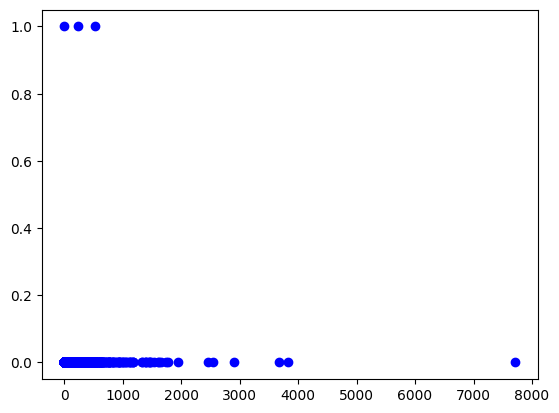

In [ ]:
# Create scatter plot
plt.scatter(creditcard_df['Amount'], creditcard_df['Class'], c="blue")

# Show the plot
plt.show()

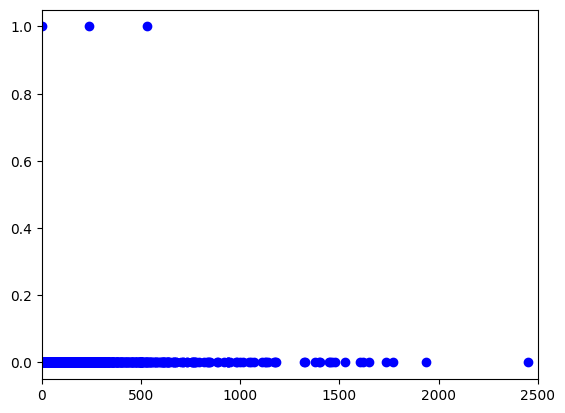

In [ ]:
# Create scatter plot
plt.scatter(creditcard_df['Amount'], creditcard_df['Class'], c="blue")

plt.xlim(0,2500)

# Show the plot
plt.show()

Fruad transanction is below the amount of 2500

<Axes: >

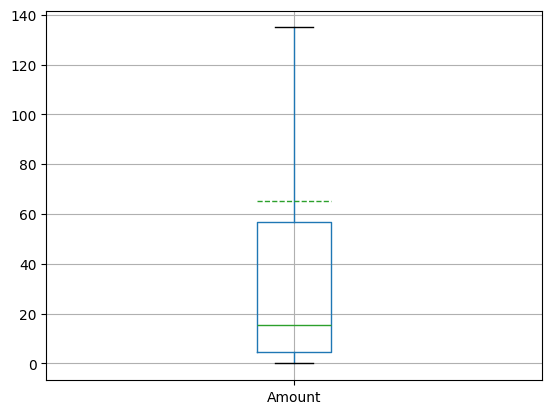

In [ ]:
creditcard_df[['Amount']].boxplot(showfliers=False, meanline=True, showmeans=True)


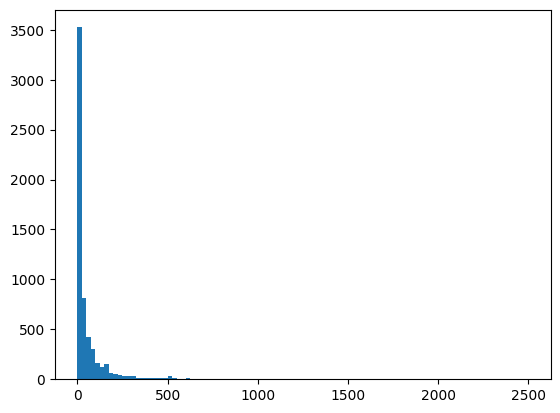

In [ ]:
plt.hist(creditcard_df['Amount'], bins= 100, range = (0, 2500))
plt.show()

<Axes: >

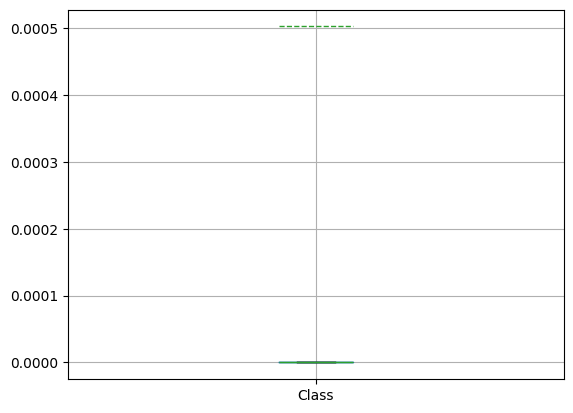

In [ ]:
creditcard_df[['Class']].boxplot(showfliers=False, meanline=True, showmeans=True)

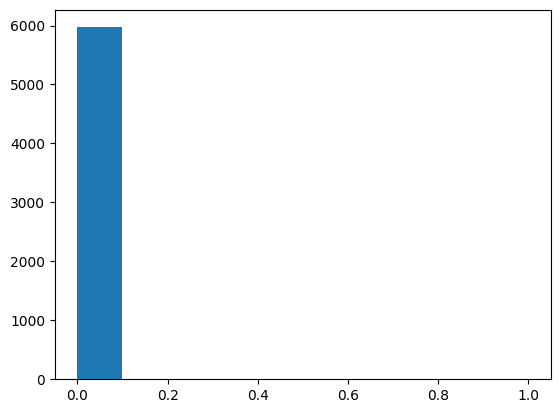

In [ ]:
plt.hist(creditcard_df['Class'])
plt.show()

In [ ]:
creditcard_df['Class'].sum(axis =0)

np.float64(3.0)

Hihgly imbalanced data

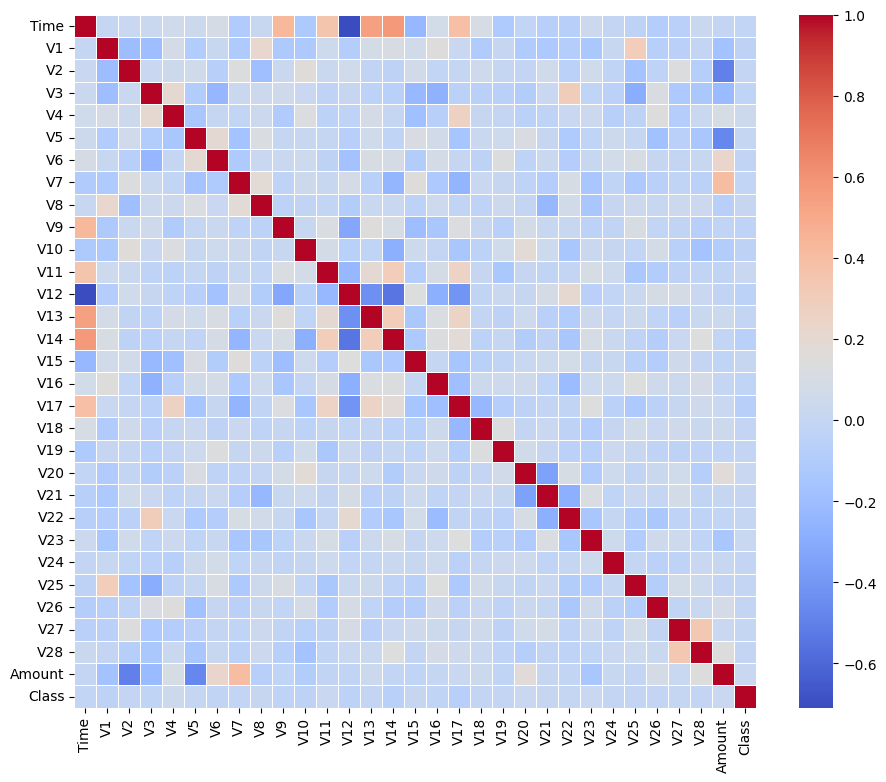

In [ ]:
# Assuming 'df' is your DataFrame and it's already loaded with data.
# Calculate the correlation matrix
corr = creditcard_df.corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a heatmap
sns.heatmap(corr, annot=False, ax=ax, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Show the plot
plt.show()

most of the columns are uncorrelated so we will use all of them for Supervised Machine Learning and for the purpose of feature Selection we are not merging the same columns

***Group by anaylsis***

*class*

We have grouped the data set into class and other variables as V1 , V2 ....., Amount

In [ ]:
grouped_class_df = creditcard_df.groupby('Class')

In [ ]:
grouped_class_df.describe()

Time                                                            \
        count        mean          std    min      25%     50%      75%   
Class                                                                     
0.0    5970.0  2677.40201  1764.242849    0.0  1163.25  2537.0  3779.75   
1.0       3.0  1780.00000  2322.914549  406.0   439.00   472.0  2467.00   

                   V1                                                     \
          max   count      mean       std        min       25%       50%   
Class                                                                      
0.0    6644.0  5970.0 -0.264965  1.394904 -12.168192 -1.014956 -0.420160   
1.0    4462.0     3.0 -2.553039  0.424810  -3.043541 -2.677884 -2.312227   

                               V2                                           \
            75%       max   count      mean       std        min       25%   
Class                                                                        
0.0    1.115778  1.685314  5970.0  0.285625  1.208096 -15.732974 -0.280054   
1.0   -2.307788 -2.303350     3.0  0.184644  2.895819  -3.157307 -0.699030   

                                         V3                                 \
            50%       75%       max   count      mean       std        min   
Class                                                                        
0.0    0.346083  0.941314  7.467017  5970.0  0.844580  1.031037 -12.389545   
1.0    1.759247  1.855620  1.951992     3.0 -0.293711  1.350368  -1.609851   

                                                   V4                      \
            25%       50%       75%       max   count      mean       std   
Class                                                                       
0.0    0.296186  0.882882  1.504158  4.101716  5970.0  0.102656  1.441327   
1.0   -0.984798 -0.359745  0.364359  1.088463     3.0  2.872264  0.975056   

                                                             V5            \
            min       25%       50%       75%       max   count      mean   
Class                                                                       
0.0   -4.657545 -0.840078  0.160580  1.070110  6.013346  5970.0  0.000958   
1.0    2.288644  2.309443  2.330243  3.164074  3.997906     3.0  0.005330   

                                                                         V6  \
            std        min       25%       50%       75%        max   count   
Class                                                                         
0.0    1.185941 -32.092129 -0.608995 -0.083455  0.441406  10.658654  5970.0   
1.0    1.182527  -0.821628 -0.671908 -0.522188  0.418809   1.359805     3.0   

                                                                              \
           mean       std       min       25%       50%       75%        max   
Class                                                                          
0.0    0.195420  1.365712 -7.465603 -0.677446 -0.142606  0.605955  21.393069   
1.0   -0.855718  0.699235 -1.426545 -1.245684 -1.064823 -0.570305  -0.075788   

           V7                                                               \
        count      mean       std        min       25%       50%       75%   
Class                                                                        
0.0    5970.0  0.018542  1.059665 -12.968670 -0.492968  0.041590  0.566461   
1.0       3.0 -0.549831  1.725340  -2.537387 -1.105907  0.325574  0.443947   

                      V8                                                     \
             max   count      mean       std        min       25%       50%   
Class                                                                         
0.0    34.303177  5970.0 -0.039195  1.304302 -23.632502 -0.189736  0.037831   
1.0     0.562320     3.0  0.308239  0.952783  -0.399147 -0.233470 -0.067794   

                               V9                                          \
            75%       max   count    

In [ ]:
grouped_class_df.size()

,0
Class,
0.0,5970
1.0,3


In [ ]:
grouped_class1_df = grouped_class_df.get_group(1)

In [ ]:
grouped_class1_df.sample(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
4920,4462,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,2.032912,-6.560124,0.022937,-1.470102,-0.698826,-2.282194,-4.781831,-2.615665,-1.334441,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1.0
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,-0.016822,0.416956,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1.0
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1.0


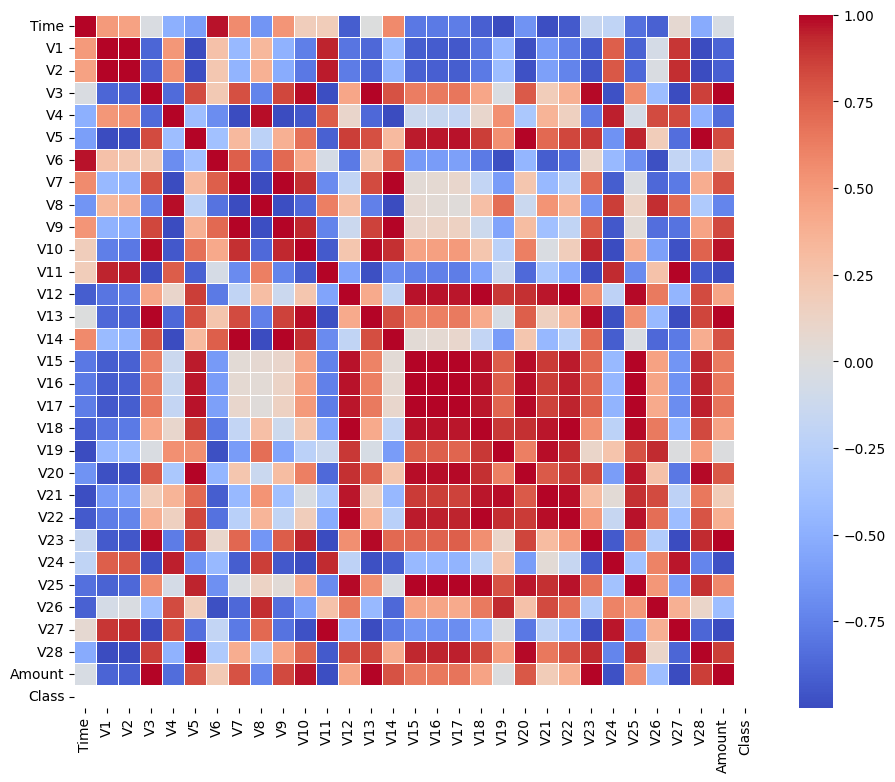

In [ ]:
# Assuming 'df' is your DataFrame and it's already loaded with data.
# Calculate the correlation matrix
corr =grouped_class1_df.corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a heatmap
sns.heatmap(corr, annot=False, ax=ax, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Show the plot
plt.show()

There are certain varibles for eg. V1 and V3 are highly correlated for fraudulent transaction

In [ ]:
grouped_class0_df = grouped_class_df.get_group(0)

In [ ]:
grouped_class0_df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2854,2423,-0.323035,0.706652,0.895412,-2.152060,0.423785,-1.217130,1.170274,-0.417092,0.852196,-1.152017,-0.769283,0.114536,-0.026639,0.029408,0.908749,-0.440510,-0.757404,0.192332,0.085814,0.052831,0.028856,0.471348,-0.358871,-0.106178,0.143149,-0.808874,0.238887,-0.018516,1.00,0.0
5509,5558,1.318829,0.079598,-0.947571,-0.353669,2.104616,3.315095,-0.628006,0.727755,1.232257,-0.369337,0.918943,-2.433274,1.681065,1.860111,0.507794,0.611091,-0.177928,0.204646,0.052105,-0.026702,-0.463925,-1.255073,0.115733,0.931089,0.346348,0.071795,-0.054999,0.005390,1.79,0.0
4678,4091,1.129279,0.200974,0.284464,1.499464,0.176893,0.196033,0.036717,-0.088401,1.563018,-0.521691,-0.018515,-1.995035,1.907130,1.418003,-0.819721,-0.604308,0.784656,-0.557749,-0.382976,-0.116266,-0.260213,-0.338237,-0.155176,-0.494445,0.707344,-0.323295,0.006888,0.011721,48.06,0.0
5873,6417,1.282408,0.702030,0.052703,1.297862,0.219690,-1.116206,0.539052,-0.503245,0.826751,-0.359671,0.784000,-1.660779,2.824459,1.761773,-0.185487,-0.300644,0.350078,-0.241203,-0.462212,-0.123420,-0.134583,-0.022951,-0.147833,0.372419,0.870612,-0.338633,-0.026793,0.006941,1.00,0.0
42,33,-0.607877,1.031345,1.740450,1.232106,0.418592,0.119168,0.850893,-0.176267,-0.243501,0.148455,-0.387003,0.398299,0.481917,-0.365439,0.235545,-1.347811,0.504648,-0.798405,0.759710,0.254325,-0.087329,0.258315,-0.264775,0.118282,0.173508,-0.217041,0.094312,-0.033041,14.80,0.0


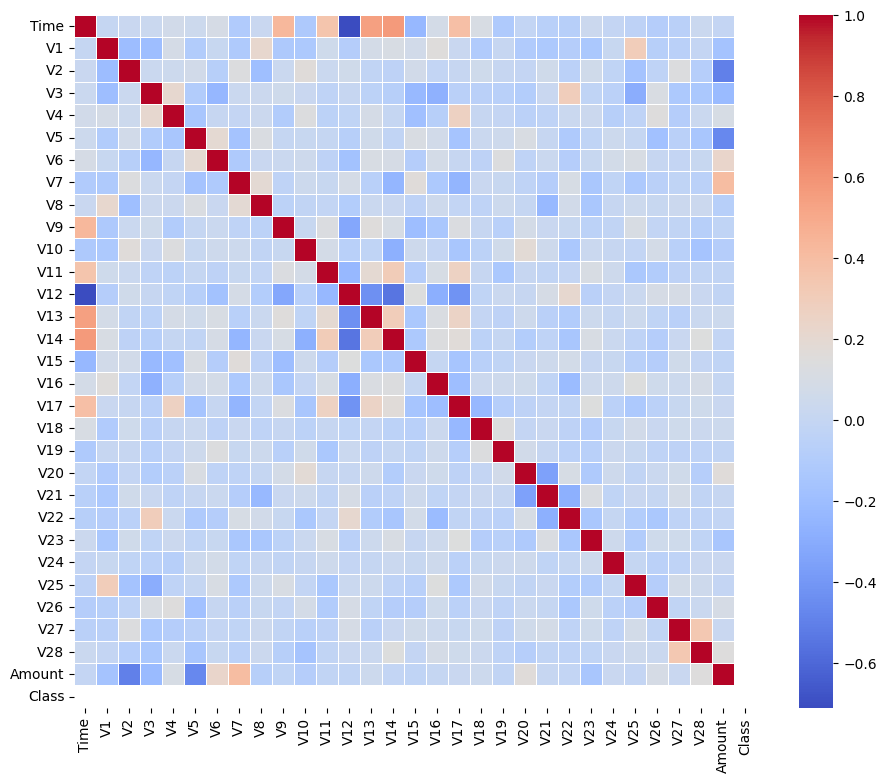

In [ ]:
# Assuming 'df' is your DataFrame and it's already loaded with data.
# Calculate the correlation matrix
corr =grouped_class0_df.corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a heatmap
sns.heatmap(corr, annot=False, ax=ax, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Show the plot
plt.show()

For the observation purpose we can observe that in case of both fraudulent and non fraudulent transactions the variables from V1 to V17 are correlated

*Amount*

Again we have grouped the dataset into amount and other variables like V1, V2 .... and amount which is additional work in our analysis

After grouping pair plotting has been performed to have better visualisation of the data

In [ ]:
creditcard_df['Amount_Group'] = creditcard_df['Amount'].apply(categorize_amount)

In [ ]:
creditcard_df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Group
1898,1467,-1.673025,1.006263,0.726009,1.643772,-0.762650,-0.384575,-0.007271,0.876680,-0.547454,-0.474051,-0.475864,0.509455,-0.373958,0.723014,0.179958,-1.086795,1.165410,-0.733642,0.506734,-0.041896,0.115767,0.274870,0.017040,0.632758,-0.139780,-0.269256,0.089001,-0.025177,64.61,0.0,0-2500
5598,5764,-0.094255,0.373340,1.175382,0.627407,-0.160934,0.310964,0.927078,-0.983293,0.928696,1.421688,0.319144,-2.850179,1.707957,0.491084,-0.855800,-2.854832,1.056708,0.772647,-0.624793,-0.585970,-0.559566,-0.157548,0.158081,-0.007013,-1.211904,-0.627710,-0.852221,-0.525718,76.19,0.0,0-2500
1485,1159,0.676930,-0.459534,0.312400,2.858781,-0.422098,0.172131,0.229546,0.122043,-0.104288,0.470746,-1.078338,-0.983492,-2.398922,0.529352,-0.252149,-0.082052,0.250613,-0.775104,-1.005276,0.121781,-0.006262,-0.485439,-0.198179,0.036207,0.386343,0.019156,-0.048656,0.050128,239.02,0.0,0-2500
1578,1232,-2.780321,1.029745,-0.912468,-2.098689,-0.491635,-1.646703,-0.326314,0.981057,0.563343,-1.185552,-0.291022,1.450715,1.008532,0.970063,1.167316,-0.720586,0.538755,-0.704472,0.182256,-0.131440,0.131998,0.325925,-0.475175,0.193596,-0.090166,-0.130921,0.092622,-0.080756,1.00,0.0,0-2500
4832,4324,1.091217,-0.083996,1.265521,1.311345,-0.571454,0.811998,-0.892402,0.361189,2.052792,-0.424688,1.651652,-1.770982,0.852250,1.434415,-0.898602,0.084818,0.436742,0.459552,-0.354697,-0.235634,-0.163712,-0.056932,-0.007213,-0.379922,0.306331,-0.412709,0.052796,0.013452,9.99,0.0,0-2500


In [ ]:
grouped_amount_df = creditcard_df.groupby('Amount_Group')

In [ ]:
grouped_amount_df.size()

,0
Amount_Group,
0-2500,5968
2500-above,6


In [ ]:
grouped_amountlow_df = grouped_amount_df.get_group('0-2500')

In [ ]:
col = grouped_amountlow_df.columns

In [ ]:
col

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_Group'],
      dtype='object')

In [ ]:
col1 = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class']

In [ ]:
col2 = ['V1', 'V2', 'V3', 'V15','Amount',
       'Class']

In [ ]:
col5 = ['V4', 'V5', 'V7', 'V8','V13','V16','V18', 'Amount',
       'Class']

col6 = ['V21', 'V22', 'V24', 'V25','V26','V23', 'Amount',
       'Class']

col4 = ['V11', 'V14', 'V28', 'V17','V6','V9','V6','Amount',
       'Class']

col2 = ['V1', 'V2', 'V3', 'V15','Amount',
       'Class']

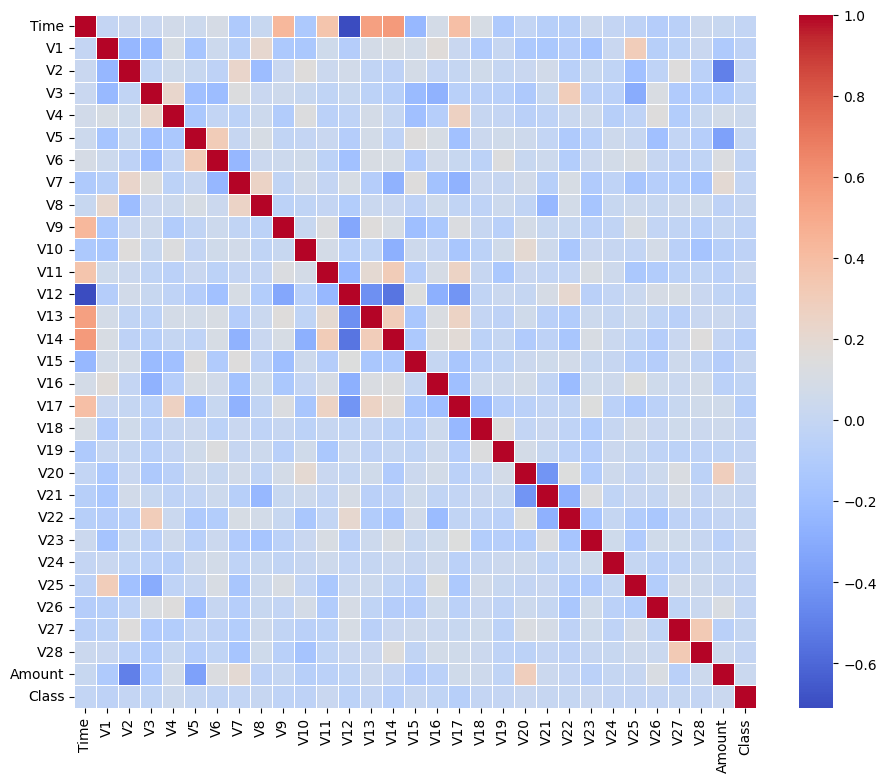

In [ ]:
# Assuming 'df' is your DataFrame and it's already loaded with data.
# Calculate the correlation matrix
corr =grouped_amountlow_df[col1].corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a heatmap
sns.heatmap(corr, annot=False, ax=ax, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Show the plot
plt.show()

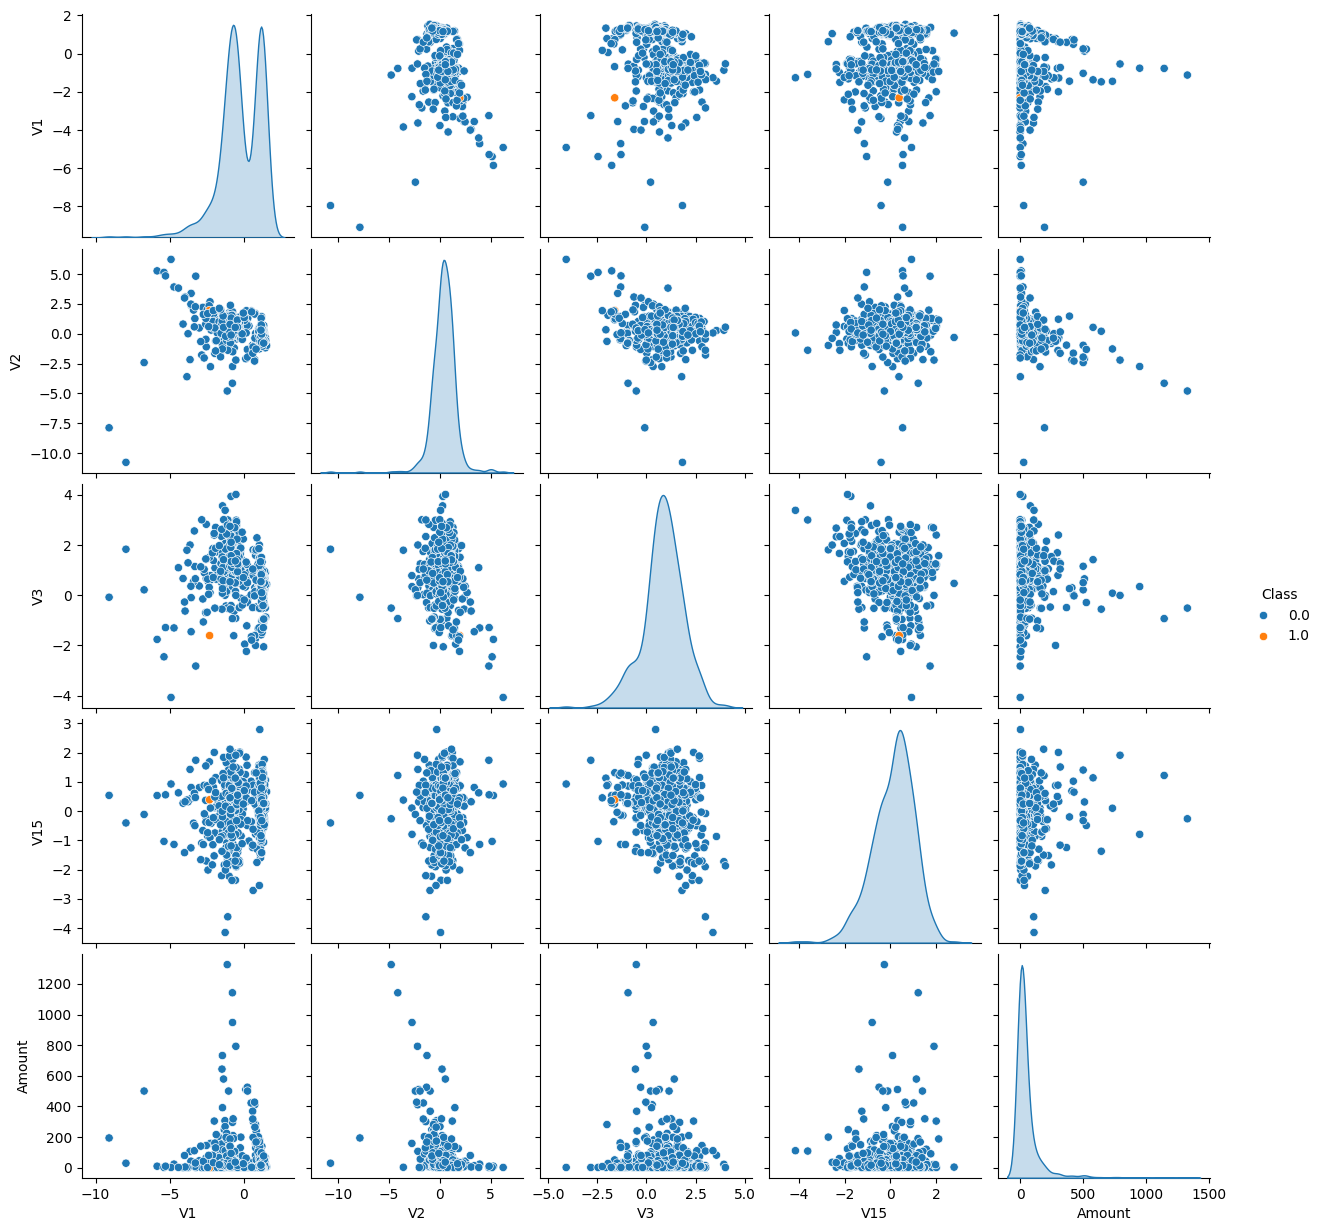

In [ ]:
sns.pairplot(grouped_amountlow_df[col2].sample(frac = 0.1), hue = 'Class')
plt.show()

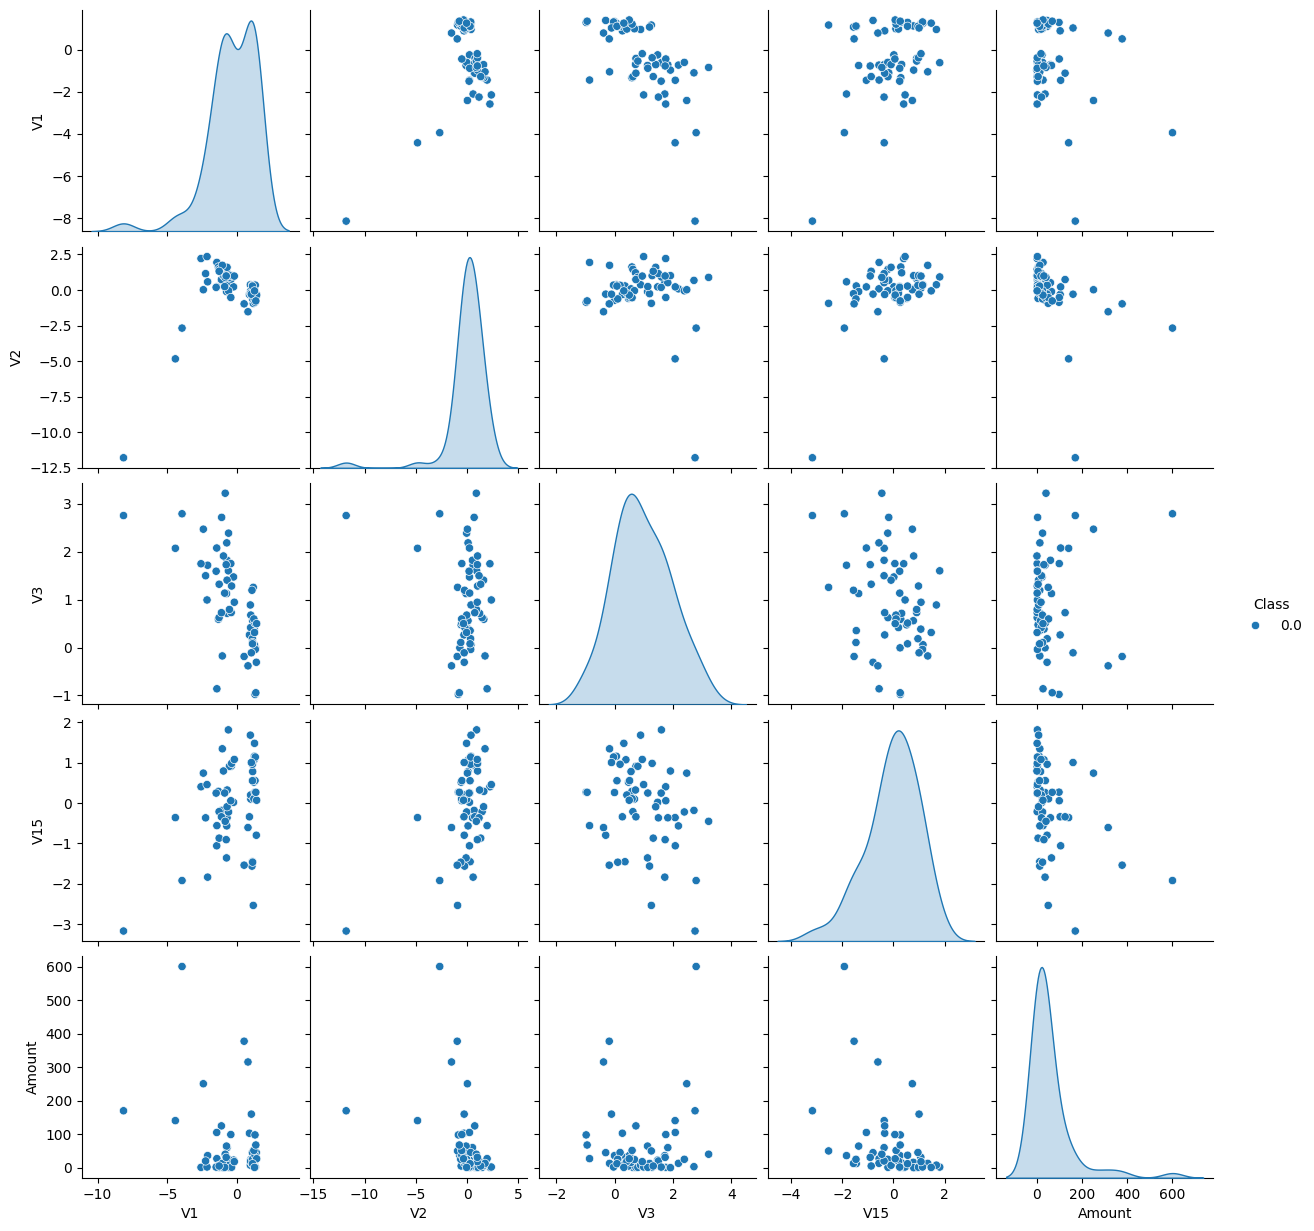

In [ ]:
sns.pairplot(grouped_amountlow_df[col2].sample(frac = 0.01), hue = 'Class')
plt.show()

In [ ]:
col3 = ['V10', 'V12', 'V20', 'V27','Amount',
       'Class']


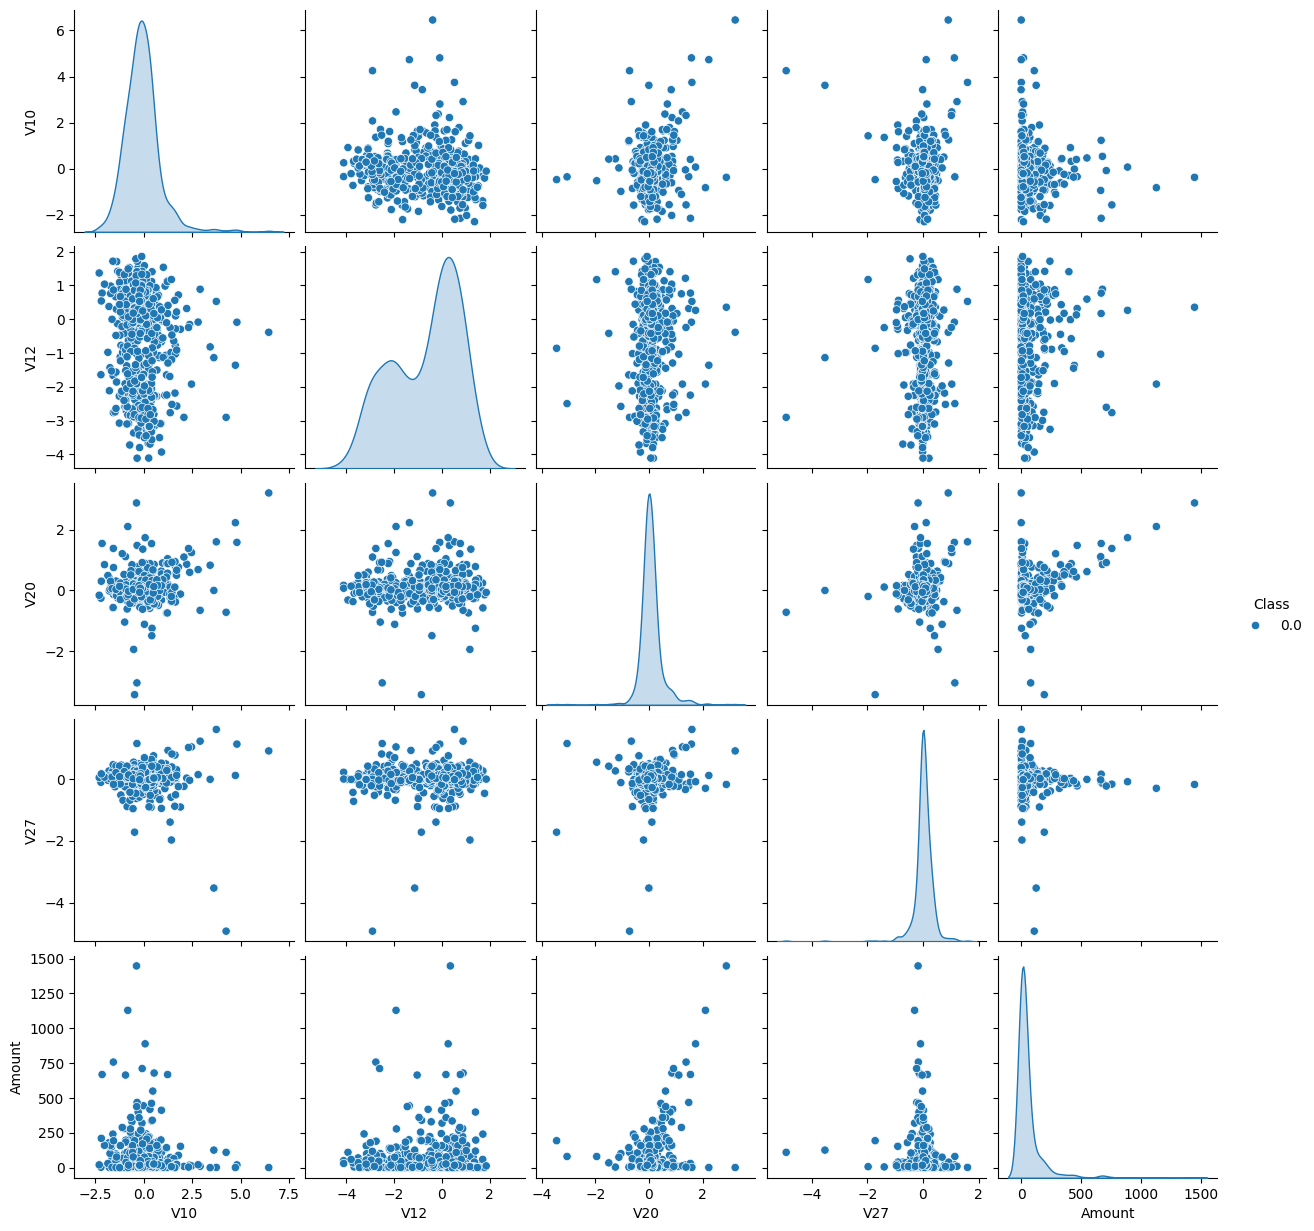

In [ ]:
sns.pairplot(grouped_amountlow_df[col3].sample(frac = 0.1), hue = 'Class')
plt.show()

In [ ]:
col4 = ['V11', 'V14', 'V28', 'V17','V6','V9','V6','Amount',
       'Class']
col5 = ['V4', 'V5', 'V7', 'V8','V13','V16','V18', 'Amount',
       'Class']

col6 = ['V21', 'V22', 'V24', 'V25','V26','V23', 'Amount',
       'Class']

col4 = ['V11', 'V14', 'V28', 'V17','V6','V9','V6','Amount',
       'Class']

col2 = ['V1', 'V2', 'V3', 'V15','Amount',
       'Class']


In [ ]:
#sns.pairplot(grouped_amountlow_df[col4].sample(frac = 0.1), hue = 'Class')
#plt.show()

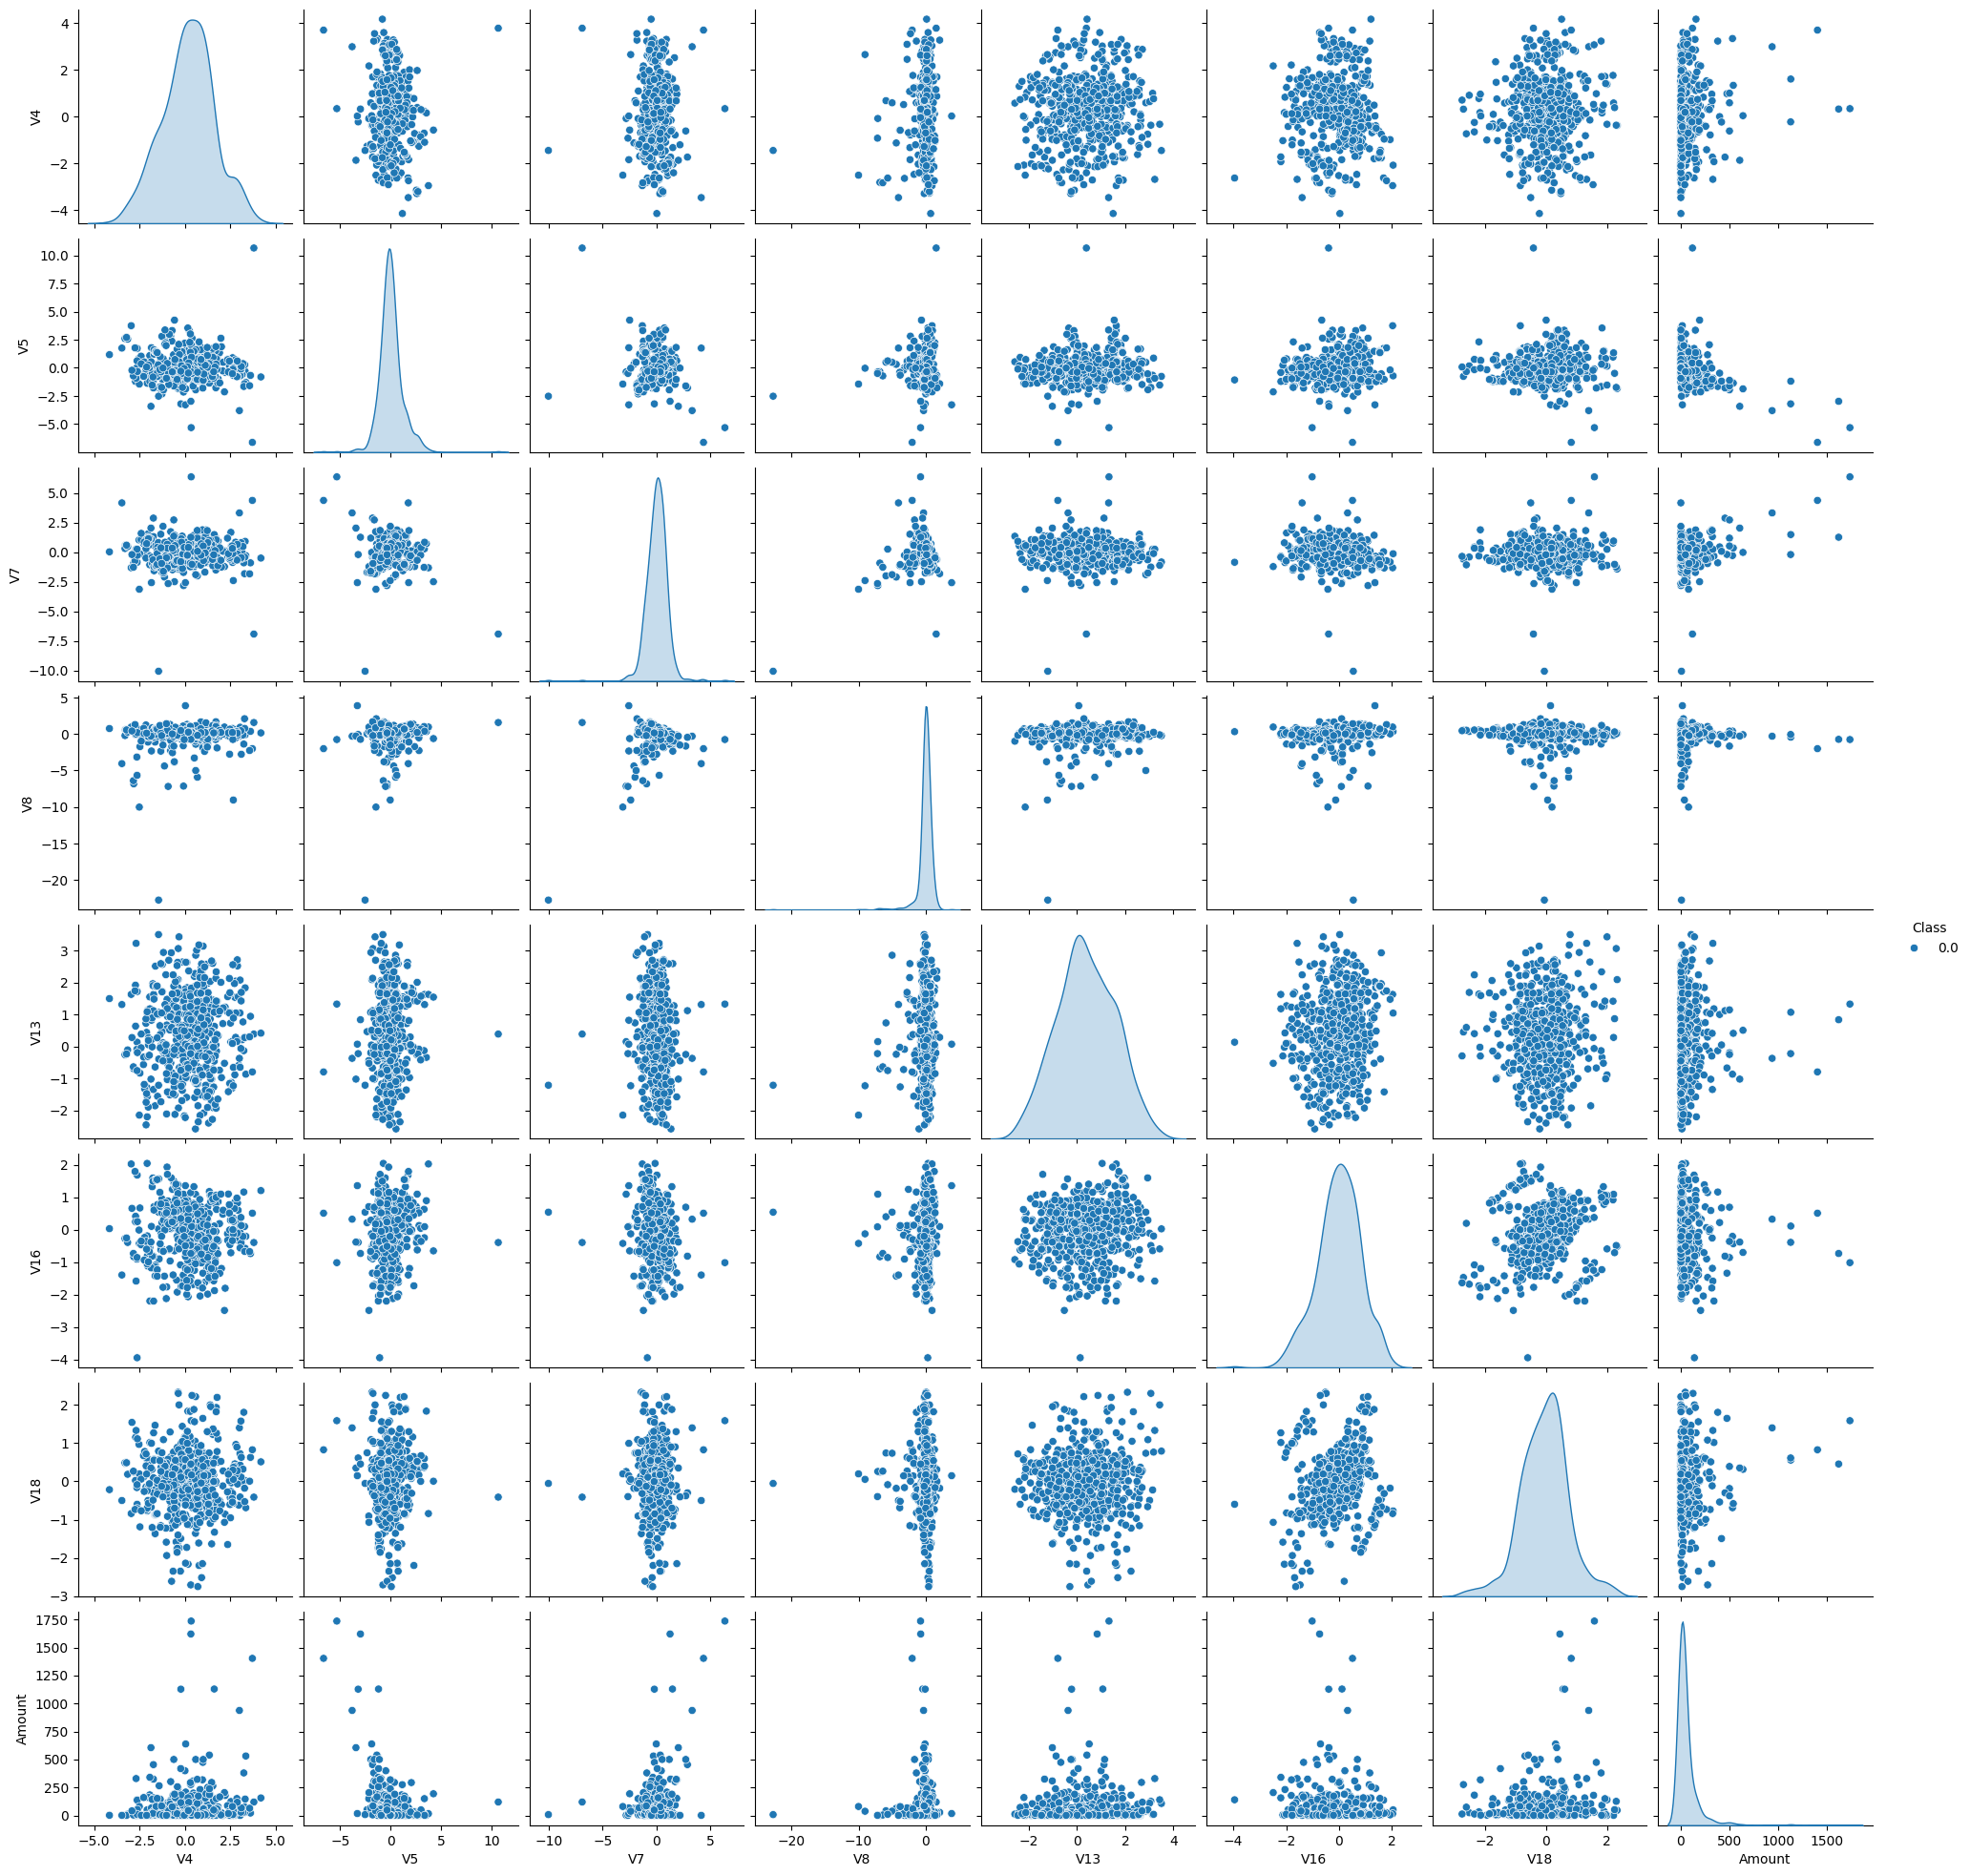

In [ ]:
sns.pairplot(grouped_amountlow_df[col5].sample(frac = 0.1), hue = 'Class')
plt.show()

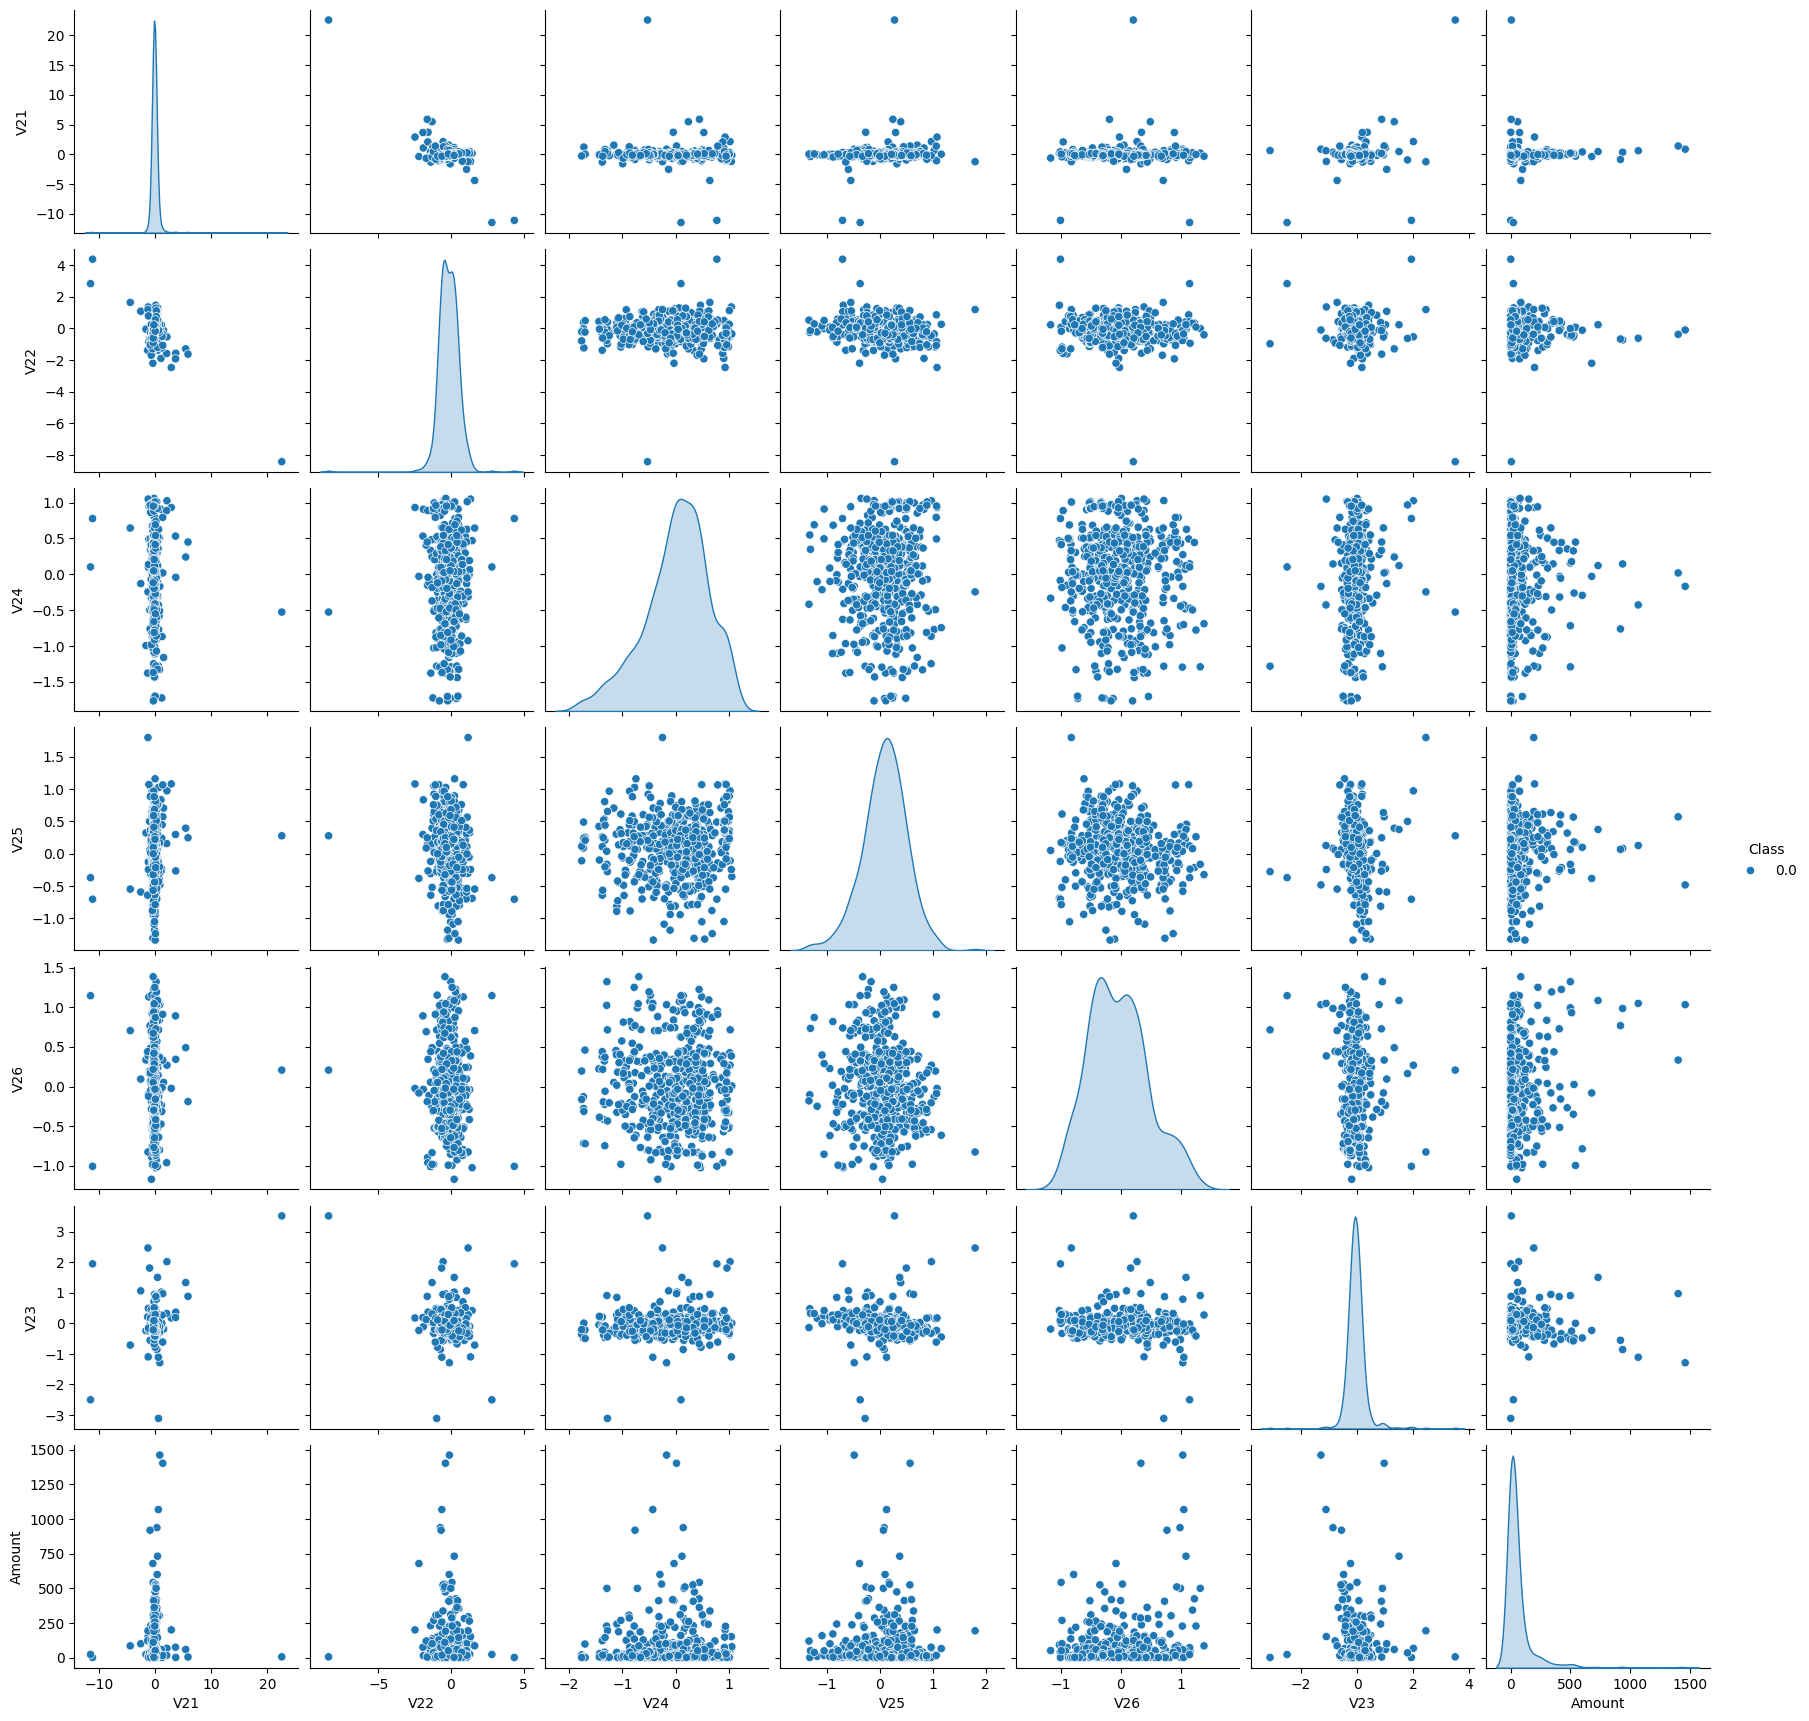

In [ ]:
sns.pairplot(grouped_amountlow_df[col6].sample(frac = 0.1), hue = 'Class')
plt.show()

 #after pairs plotting we can identify there are some outliers which are fraud

In [ ]:
col5 = ['V4', 'V5', 'V7', 'V8','V13','V16','V18', 'Amount',
       'Class']

col6 = ['V21', 'V22', 'V24', 'V25','V26','V23', 'Amount',
       'Class']

col4 = ['V11', 'V14', 'V28', 'V17','V6','V9','V6','Amount',
       'Class']

col2 = ['V1', 'V2', 'V3', 'V15','Amount',
       'Class']

*two group*

In [ ]:
grouped_amount_class_df = creditcard_df.groupby(['Amount_Group', 'Class'])

In [ ]:
grouped_amount_class_df.size()

Amount_Group  Class
0-2500        0.0      5965
              1.0         3
2500-above    0.0         5
dtype: int64

In [ ]:
grouped_amount_class_df.sample(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Group
1365,1059,1.276077,-0.480325,0.646087,-0.432326,-1.327196,-1.319226,-0.310318,-0.340562,-1.054958,0.623382,0.196180,0.639787,1.375307,-0.100488,0.810994,-1.381280,0.056475,0.550129,-0.981387,-0.335301,-0.415414,-0.772980,0.159586,0.957534,0.047946,0.863421,-0.054515,0.026061,48.43,0.0,0-2500
1069,815,-0.883595,0.414590,1.690132,0.191986,-0.179512,-0.444619,0.610345,0.166453,-0.226746,-0.326445,0.914095,0.476736,-1.018008,0.193397,-1.040052,-0.239260,-0.074748,0.025999,0.590825,0.254870,-0.071542,-0.206545,0.073076,0.543082,-0.061590,0.209417,0.278170,0.173456,74.22,0.0,0-2500
3388,2919,-0.357294,0.810159,1.130503,-2.046830,0.291410,-1.473388,1.265371,-0.519786,0.629535,-1.189299,-0.110345,0.941221,1.130356,-0.188297,0.735688,-0.644543,-0.646950,-0.123299,-0.110829,0.116380,0.076002,0.665246,-0.312068,0.428111,0.118601,-0.844017,0.247677,-0.010778,1.00,0.0,0-2500
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1.0,0-2500
4920,4462,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,2.032912,-6.560124,0.022937,-1.470102,-0.698826,-2.282194,-4.781831,-2.615665,-1.334441,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1.0,0-2500
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,-0.016822,0.416956,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1.0,0-2500
164,103,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,-1.724899,-0.362818,0.286155,0.487836,1.259957,0.660405,0.455263,-0.497644,0.792269,-0.978442,7.744222,2.228823,-2.264037,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900,3828.04,0.0,2500-above
2178,1698,-5.849226,-11.754975,-3.333303,3.673246,-4.459583,0.659098,4.527224,-0.985512,0.237794,-1.854230,-0.644609,0.123530,0.012160,0.853694,0.960689,0.615011,-0.056334,0.515516,-1.212439,7.314347,2.160870,-1.992179,-3.240351,0.609619,-0.985548,0.089693,-0.713355,0.653060,3669.00,0.0,2500-above
2622,2151,-2.574940,-2.669331,-3.080133,2.043551,-11.416881,7.885721,12.219249,-1.828209,-1.475925,-1.965803,0.789085,-0.160786,1.934111,-0.228977,1.698030,1.427955,-1.219459,1.558758,1.643275,0.828357,-0.115580,0.264090,2.219739,-0.771131,0.145438,-0.240517,1.180441,-0.623651,2909.97,0.0,2500-above


In [ ]:
grouped_amountlow_class1_df = grouped_amount_class_df.get_group(('0-2500', 1))

In [ ]:
grouped_amountlow_class1_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.0
mean,1780.000000,-2.553039,0.184644,-0.293711,2.872264,0.005330,-0.855718,-0.549831,0.308239,-1.093098,-1.712090,1.606790,-3.321058,0.034739,-2.483795,0.563844,-0.918720,-2.337390,-0.302389,-0.211380,0.599742,0.294921,-0.177321,0.361160,-0.020311,0.056068,-0.170050,0.015979,-0.086847,256.310000,1.0
std,2322.914549,0.424810,2.895819,1.350368,0.975056,1.182527,0.699235,1.725340,0.952783,1.452409,0.980266,1.845576,3.050375,0.635944,1.567506,1.358128,1.486971,2.724391,2.184537,0.974891,1.330748,0.515252,0.694944,0.934940,0.312439,0.218185,0.360868,0.257770,0.106296,264.880121,0.0
min,406.000000,-3.043541,-3.157307,-1.609851,2.288644,-0.821628,-1.426545,-2.537387,-0.399147,-2.770089,-2.772272,-0.414575,-6.560124,-0.595222,-4.289254,-0.698826,-2.282194,-4.781831,-2.615665,-1.334441,-0.430022,-0.294166,-0.932391,-0.465211,-0.293803,-0.156114,-0.542628,-0.252773,-0.153029,0.000000,1.0
25%,439.000000,-2.677884,-0.699030,-0.984798,2.309443,-0.671908,-1.245684,-1.105907,-0.233470,-1.520521,-2.148842,0.809168,-4.730016,-0.286142,-2.990641,-0.154551,-1.711471,-3.805943,-1.316244,-0.525548,-0.151556,0.111533,-0.483720,-0.146242,-0.190566,-0.055798,-0.343995,-0.106604,-0.148152,119.965000,1.0
50%,472.000000,-2.312227,1.759247,-0.359745,2.330243,-0.522188,-1.064823,0.325574,-0.067794,-0.270953,-1.525412,2.032912,-2.899907,0.022937,-1.692029,0.389724,-1.140747,-2.830056,-0.016822,0.283345,0.126911,0.517232,-0.035049,0.172726,-0.087330,0.044519,-0.145362,0.039566,-0.143276,239.930000,1.0
75%,2467.000000,-2.307788,1.855620,0.364359,3.164074,0.418809,-0.570305,0.443947,0.661932,-0.254603,-1.181999,2.617473,-1.701524,0.349719,-1.581065,1.195179,-0.236984,-1.115169,0.854249,0.350150,1.114625,0.589464,0.200214,0.774346,0.116434,0.162159,0.016239,0.150355,-0.053756,384.465000,1.0
max,4462.000000,-2.303350,1.951992,1.088463,3.997906,1.359805,-0.075788,0.562320,1.391657,-0.238253,-0.838587,3.202033,-0.503141,0.676502,-1.470102,2.000635,0.666780,0.599717,1.725321,0.416956,2.102339,0.661696,0.435477,1.375966,0.320198,0.279798,0.177840,0.261145,0.035764,529.000000,1.0


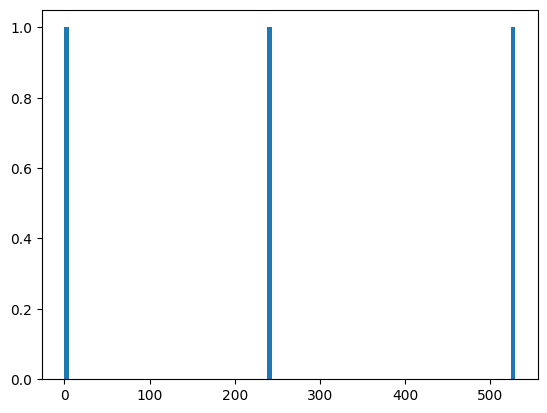

In [ ]:
plt.hist(grouped_amountlow_class1_df['Amount'], bins=100)
plt.show()

We can observe that fruad transaction via credit cards occurs at very low range of amount around 100 dollars

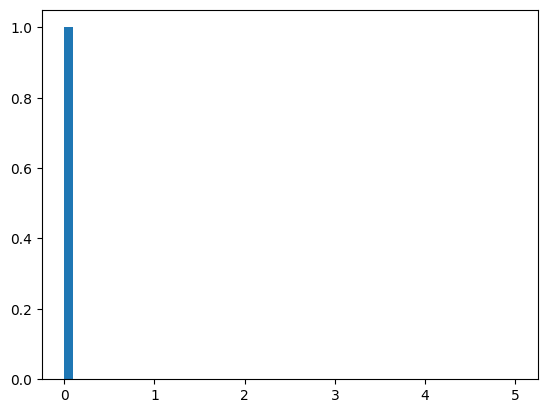

In [ ]:
plt.hist(grouped_amountlow_class1_df['Amount'], range=(0,5), bins=50)
plt.show()

For fruadlent transaction mode of amount =1 dollar

In [ ]:
grouped_amountlow_class0_df = grouped_amount_class_df.get_group(('0-2500', 0))

In [ ]:
grouped_amountlow_class0_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.000000,5965.0
mean,2678.433361,-0.260267,0.293392,0.849739,0.099912,0.009800,0.189499,0.008791,-0.037403,0.398599,-0.106577,0.461088,-0.608897,0.414877,0.379834,0.081274,-0.043157,0.177913,-0.108585,-0.014334,0.054008,-0.043437,-0.160971,-0.035101,0.028715,0.090189,-0.040207,0.024728,0.005278,61.556649,0.0
std,1764.492849,1.383384,1.174307,1.010170,1.438161,1.098837,1.333253,0.945242,1.300975,1.046612,0.986074,1.087221,1.434063,1.208126,1.002062,0.925124,0.841551,0.798376,0.798985,0.800838,0.531482,0.880663,0.645094,0.363758,0.619782,0.407378,0.488348,0.360700,0.259318,142.497839,0.0
min,0.000000,-12.168192,-15.732974,-4.797899,-4.657545,-9.749440,-7.465603,-12.968670,-23.632502,-3.336805,-6.042641,-2.595325,-4.689183,-3.389510,-6.576789,-4.152532,-4.166708,-5.400014,-3.890140,-4.575941,-5.571503,-11.468435,-8.454599,-7.996811,-2.512377,-2.322906,-1.338556,-7.976100,-2.909294,0.000000,0.0
25%,1163.000000,-1.013287,-0.275823,0.298481,-0.840293,-0.607089,-0.677807,-0.493156,-0.188678,-0.262927,-0.621078,-0.345927,-1.901919,-0.409489,-0.178291,-0.492817,-0.571860,-0.366341,-0.566410,-0.492952,-0.139288,-0.260507,-0.594098,-0.186965,-0.350588,-0.152376,-0.399334,-0.049522,-0.017776,4.450000,0.0
50%,2542.000000,-0.417917,0.348300,0.883952,0.159421,-0.080431,-0.143842,0.041299,0.038497,0.361165,-0.176167,0.451884,-0.131786,0.348676,0.290517,0.218982,0.005392,0.102150,-0.073162,-0.004415,0.004380,-0.111901,-0.177197,-0.046752,0.094946,0.106439,-0.079583,0.015976,0.019392,15.590000,0.0
75%,3782.000000,1.116050,0.941608,1.504623,1.067040,0.441699,0.605521,0.564873,0.343650,0.961713,0.279054,1.230695,0.514785,1.280138,1.129573,0.724098,0.507853,0.623270,0.367828,0.507019,0.178141,0.059253,0.273148,0.088038,0.435527,0.355242,0.245560,0.155136,0.082599,56.150000,0.0
max,6644.000000,1.685314,7.467017,4.101716,5.072063,10.658654,6.869370,10.784088,3.877662,9.272376,11.936393,4.354865,3.774837,3.904562,5.748734,2.927060,2.825793,4.665935,2.950374,3.097749,5.851381,22.580675,4.393846,4.095021,3.200201,1.972515,3.463246,3.372603,4.860769,2452.030000,0.0


In [ ]:
grouped_amountlow_class0_df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Group
5299,5174,-1.099540,-0.139671,1.623854,-0.310035,-2.252651,1.374979,1.806673,-0.195528,1.350469,-1.333781,1.679241,-1.670242,2.230919,0.899186,-1.309489,0.456503,0.199562,0.663752,0.597232,0.068403,-0.159353,0.002188,0.184613,0.040062,-0.356170,0.902065,0.125368,-0.034955,500.00,0.0,0-2500
4118,3744,1.190301,-0.739852,0.686299,-0.514681,-1.122014,-0.341014,-0.860350,0.086485,0.504220,0.389864,2.555280,-3.185788,-0.152651,1.899572,-0.175494,1.146382,1.158573,-1.087700,0.252894,0.003812,-0.137534,-0.502338,0.157975,0.101794,-0.008004,-0.520890,-0.027272,0.011465,69.82,0.0,0-2500
1921,1477,-0.638308,0.730690,1.621655,-0.531369,-0.207588,-0.814996,0.635055,0.069422,0.354817,-0.693428,-1.137334,-0.702805,-1.851122,0.091197,-0.535382,-0.138607,-0.027886,-0.452170,-0.074582,-0.080202,-0.218487,-0.475243,-0.140942,0.385694,-0.039724,0.382341,0.272287,0.160317,5.00,0.0,0-2500
11,10,0.384978,0.616109,-0.874300,-0.094019,2.924584,3.317027,0.470455,0.538247,-0.558895,0.309755,-0.259116,-0.326143,-0.090047,0.362832,0.928904,-0.129487,-0.809979,0.359985,0.707664,0.125992,0.049924,0.238422,0.009130,0.996710,-0.767315,-0.492208,0.042472,-0.054337,9.99,0.0,0-2500
5959,6606,1.167189,0.062969,1.003509,1.537623,-0.431013,0.423029,-0.641694,0.151267,2.135125,-0.503849,-0.115380,-2.514081,0.963016,1.300139,-0.366933,-0.240210,0.718823,0.017107,-0.707039,-0.266906,-0.070846,0.298599,-0.124386,-0.325662,0.575956,-0.183439,0.044751,0.013802,1.00,0.0,0-2500


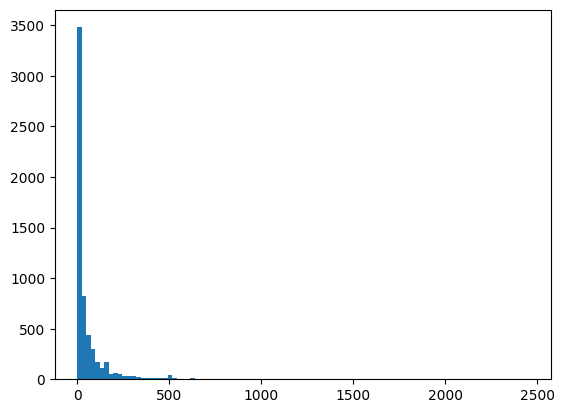

In [ ]:
plt.hist(grouped_amountlow_class0_df['Amount'], bins=100)
plt.show()

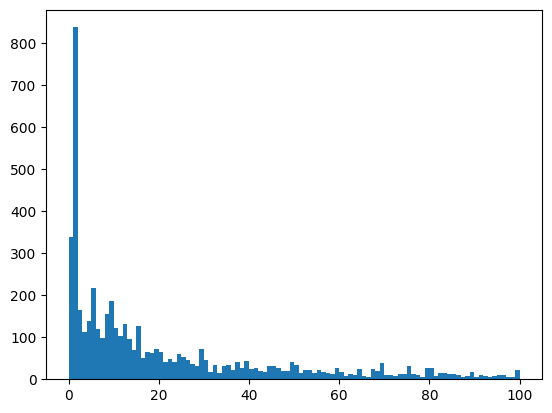

In [ ]:
plt.hist(grouped_amountlow_class0_df['Amount'],range =(0,100),  bins=100)
plt.show()

Time
NF


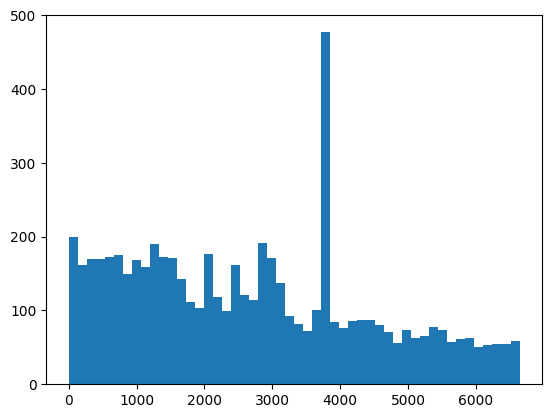

F


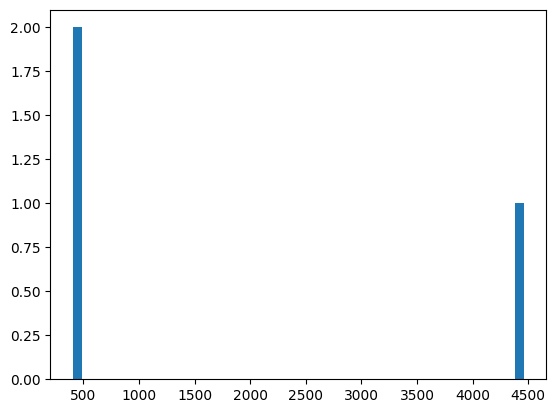

V1
NF


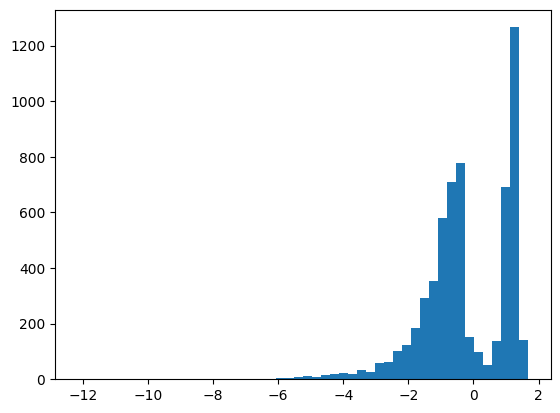

F


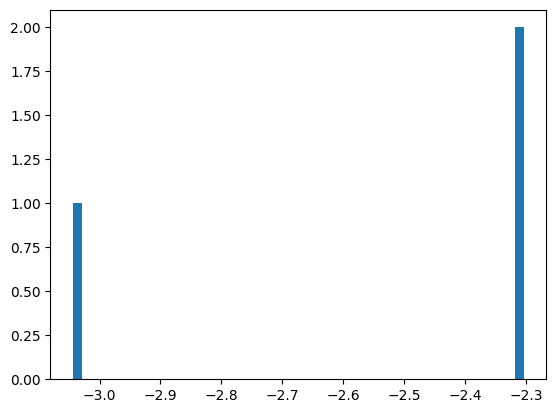

V2
NF


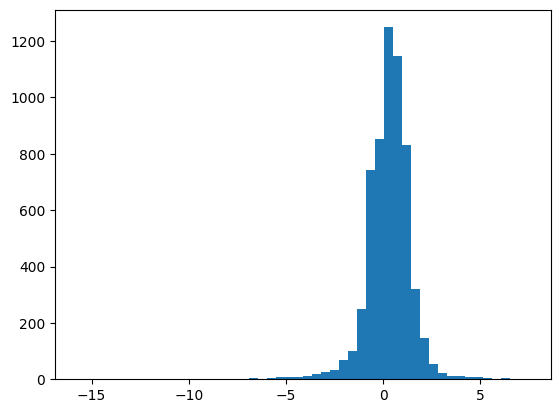

F


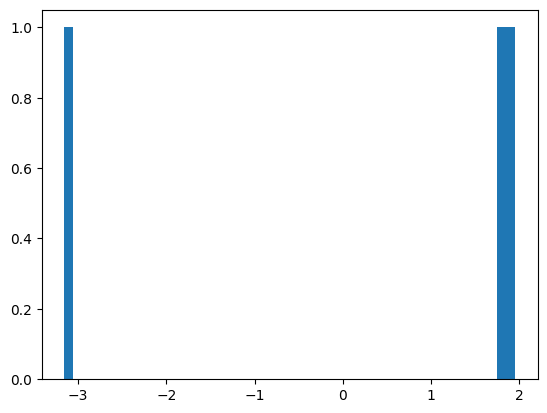

V3
NF


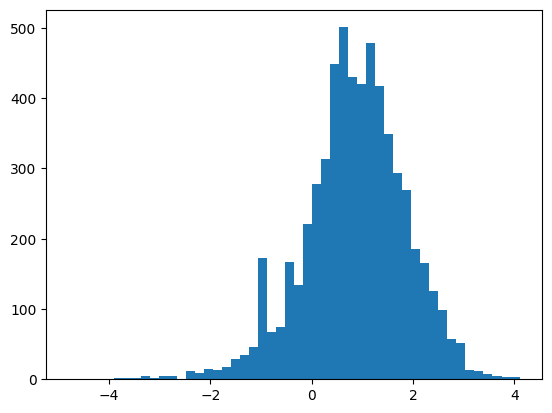

F


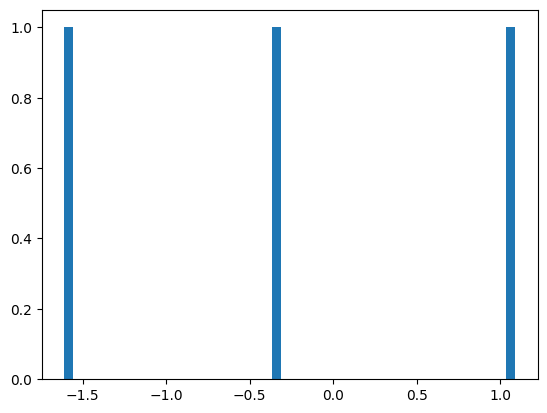

V4
NF


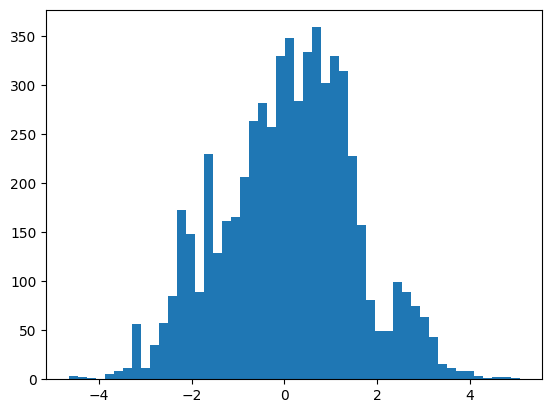

F


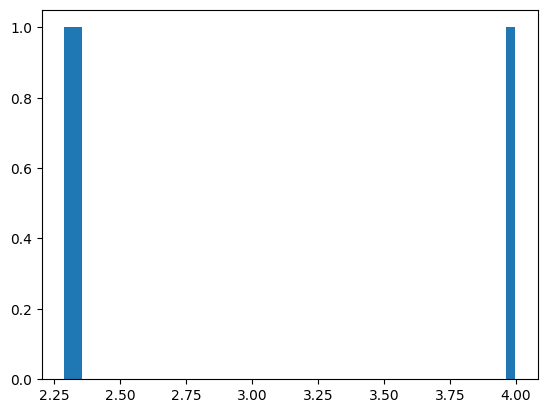

V5
NF


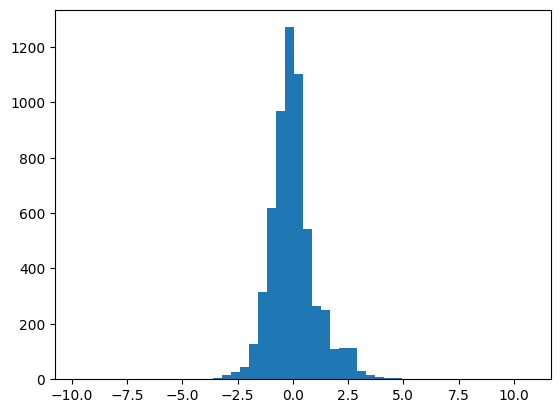

F


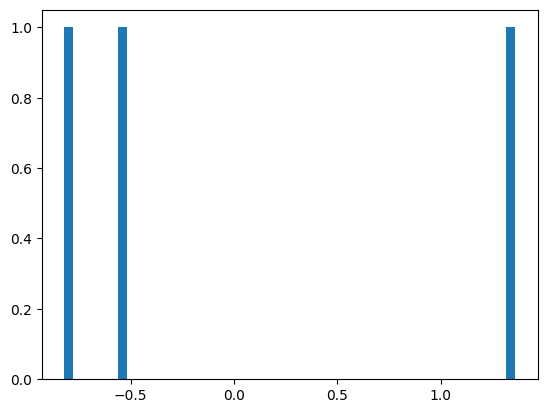

V6
NF


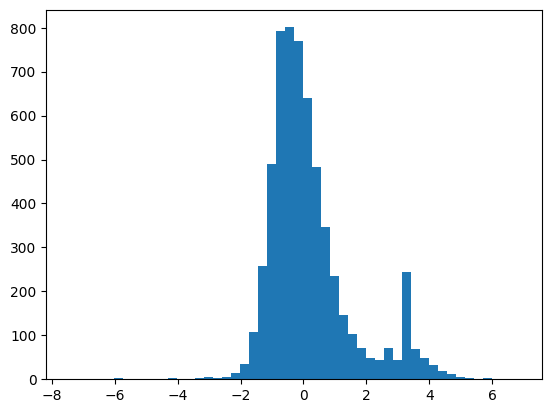

F


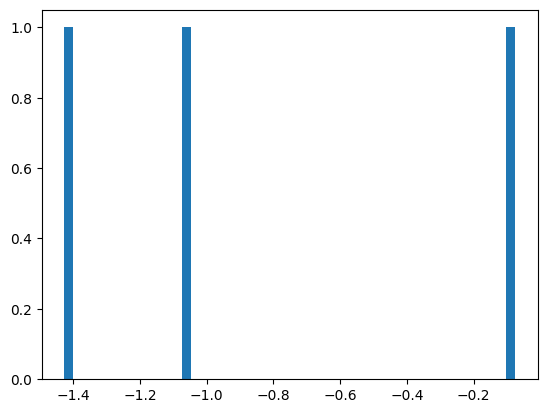

V7
NF


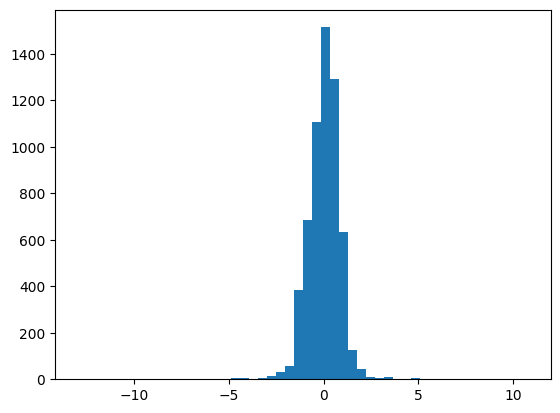

F


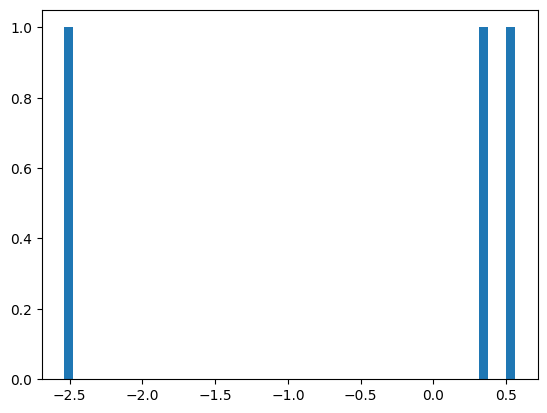

V8
NF


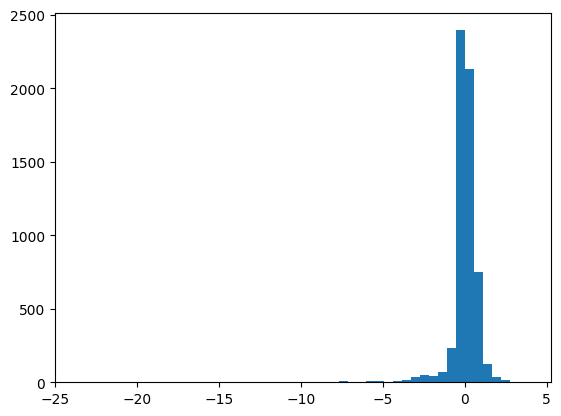

F


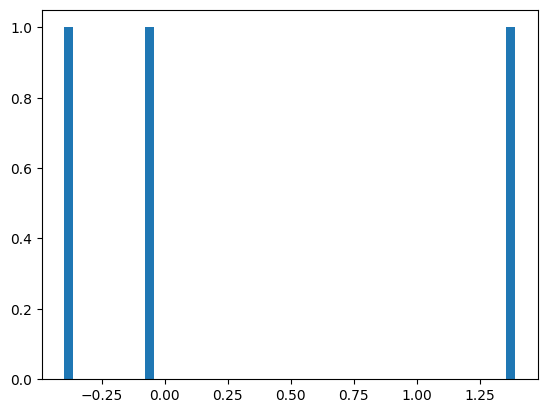

V9
NF


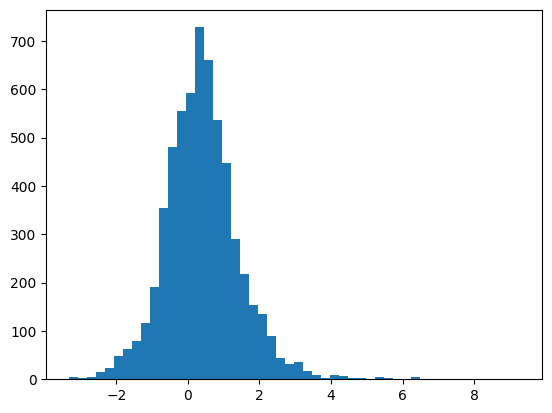

F


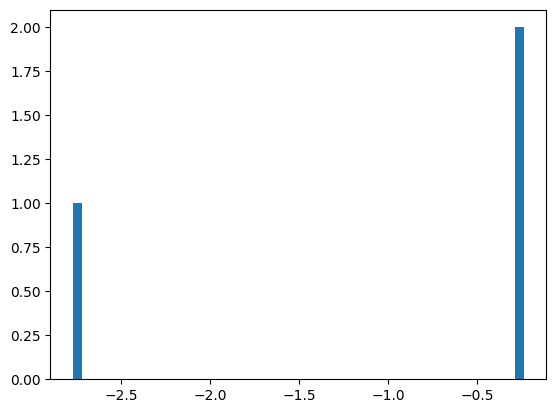

V10
NF


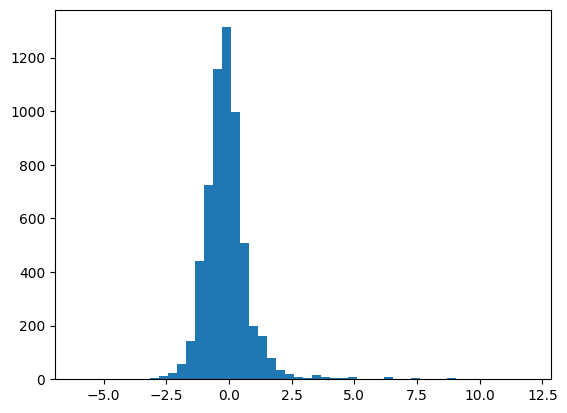

F


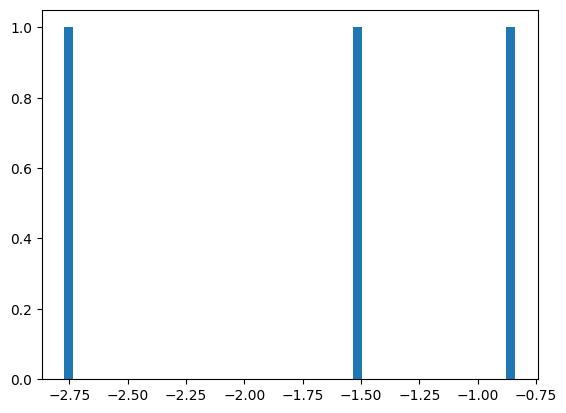

V11
NF


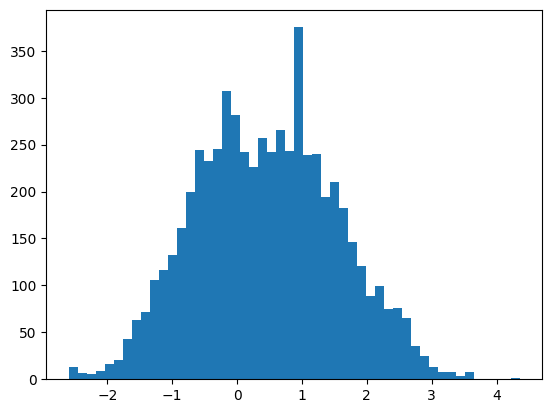

F


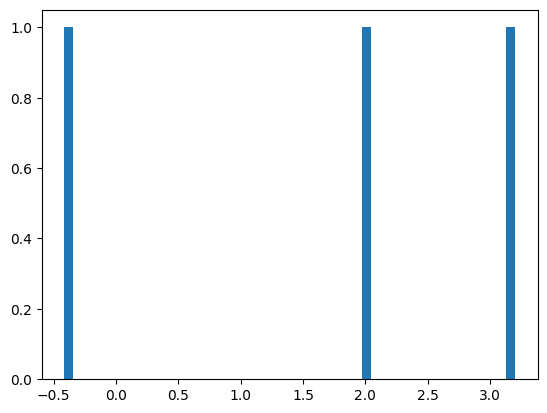

V12
NF


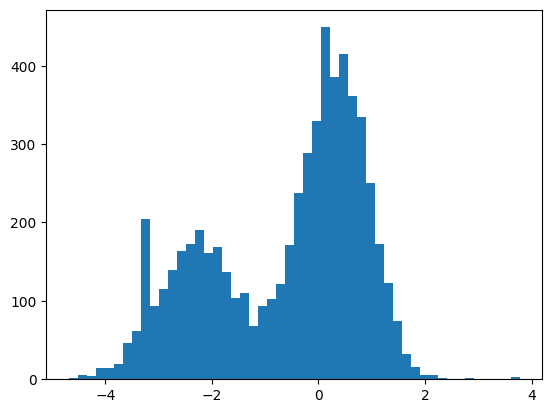

F


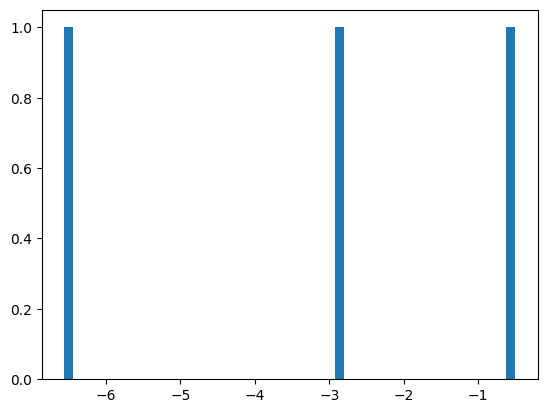

V13
NF


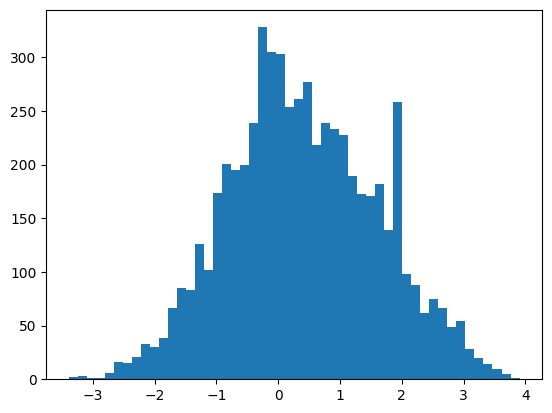

F


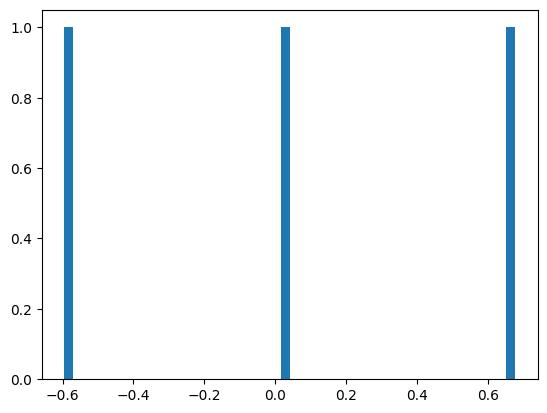

V14
NF


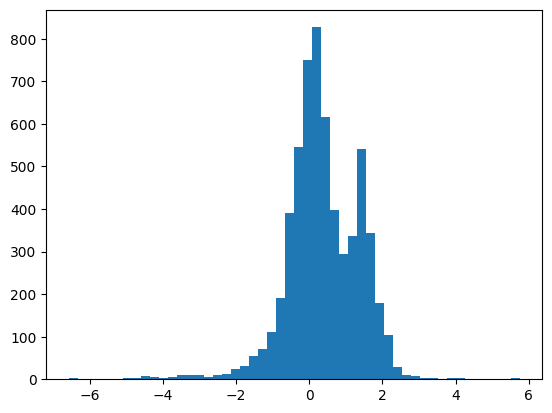

F


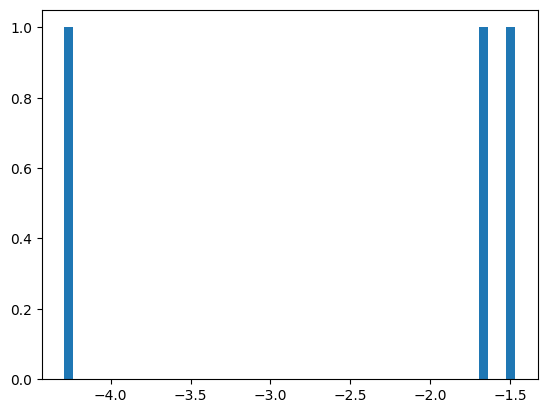

V15
NF


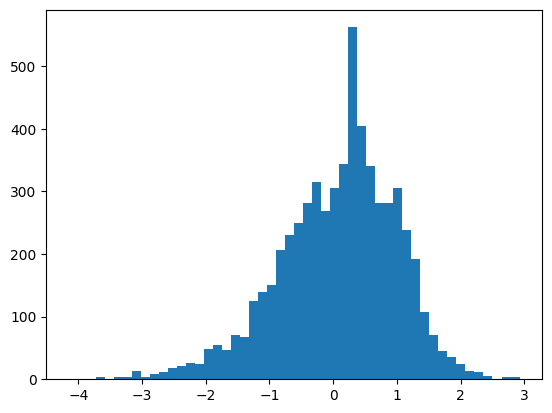

F


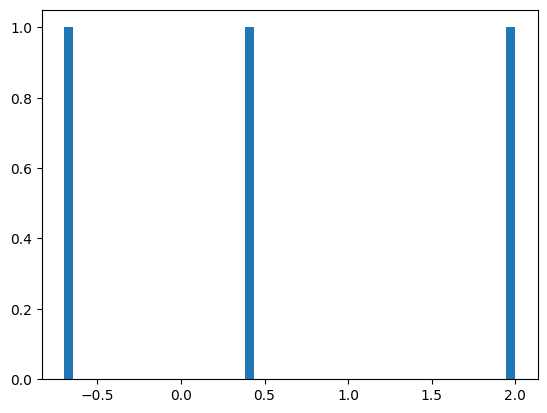

V16
NF


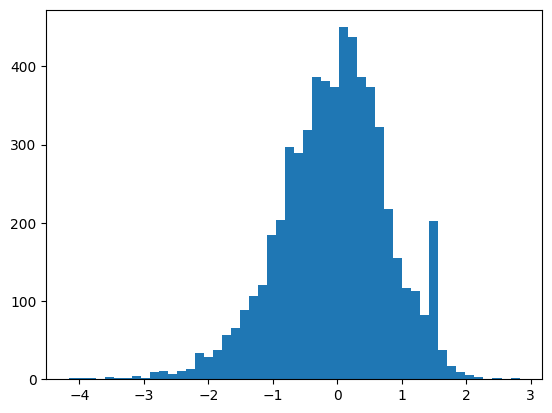

F


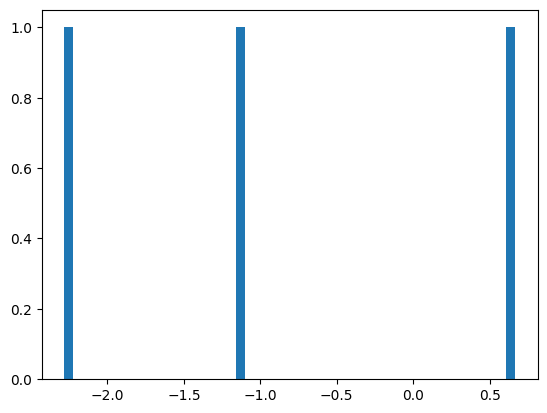

V17
NF


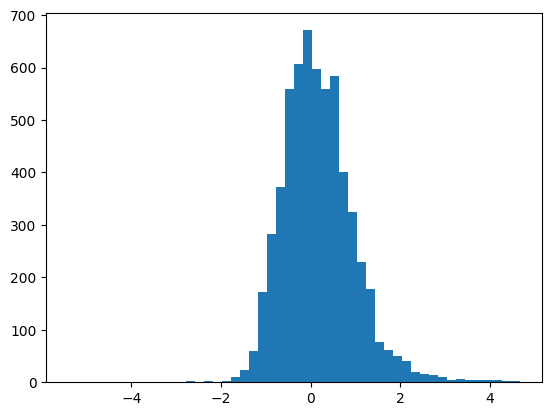

F


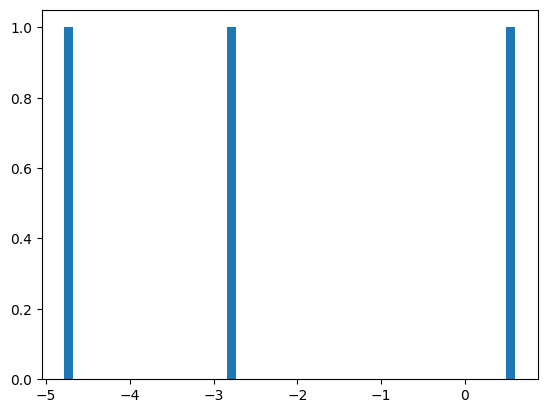

V18
NF


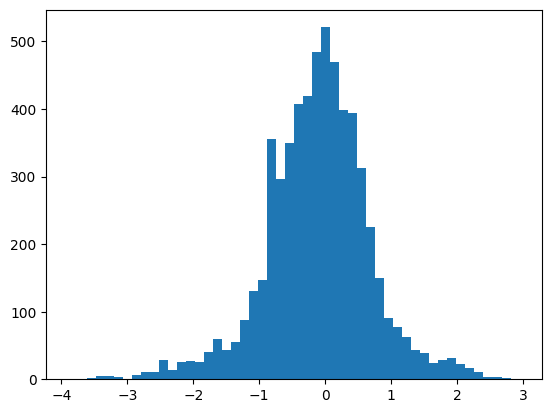

F


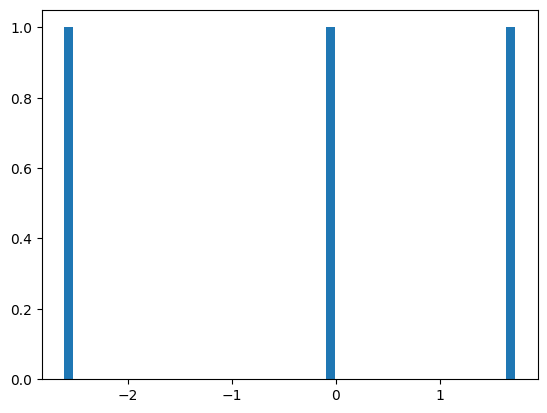

V19
NF


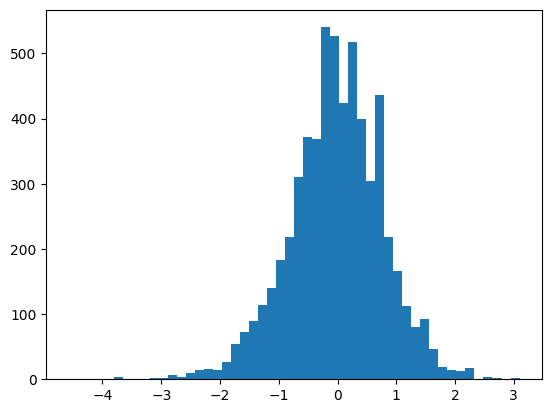

F


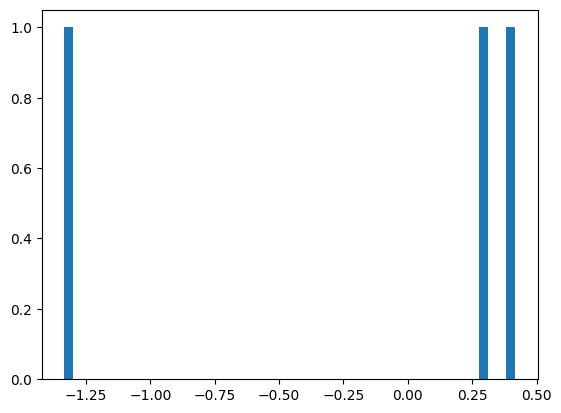

V20
NF


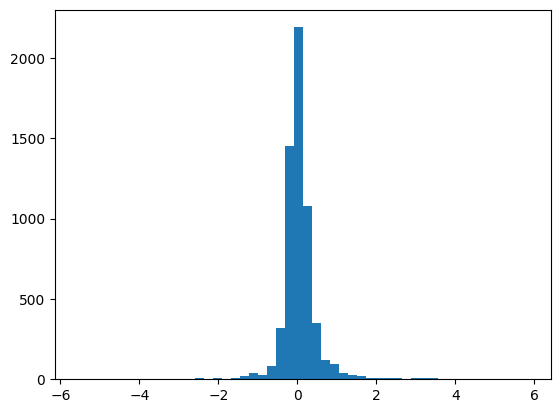

F


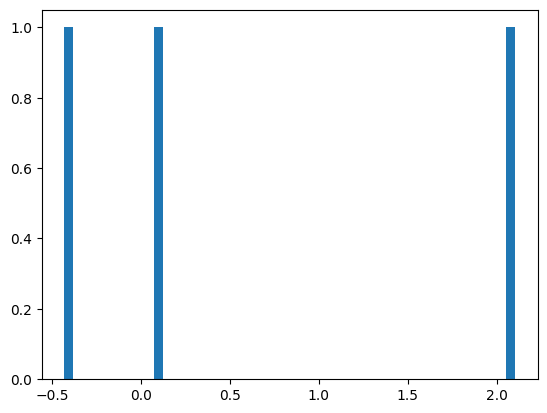

V21
NF


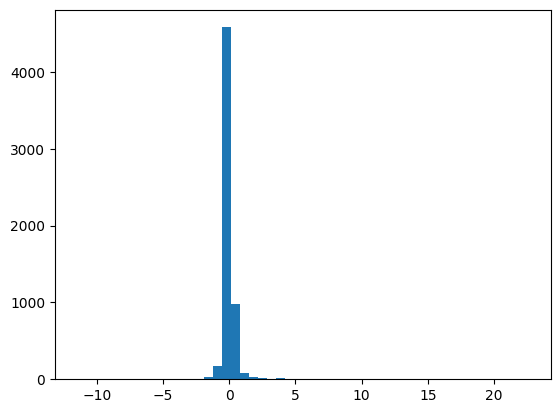

F


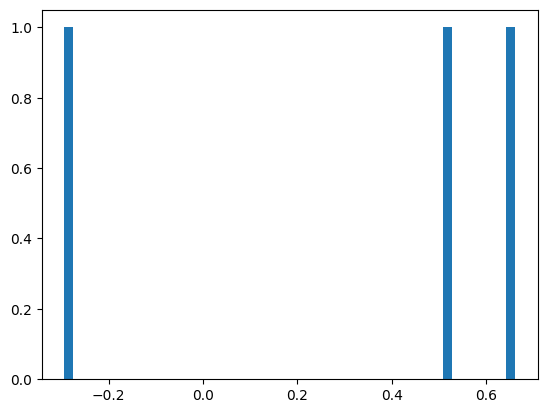

V22
NF


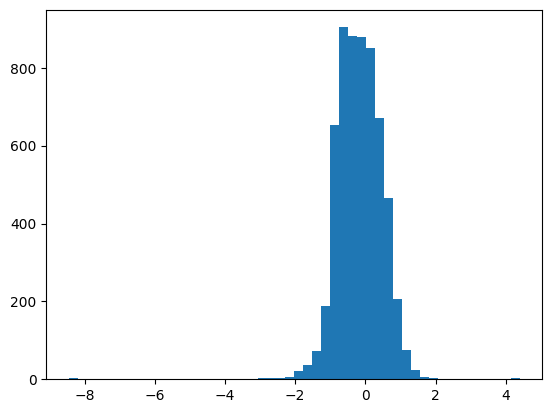

F


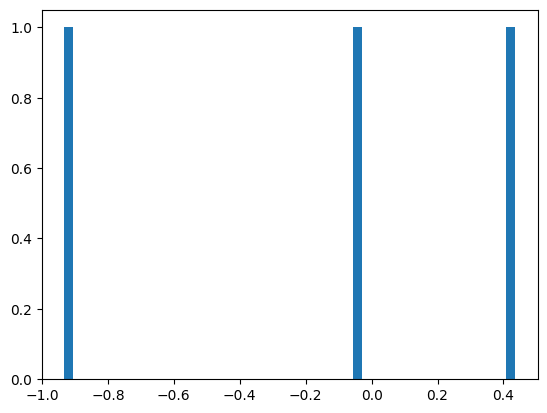

V23
NF


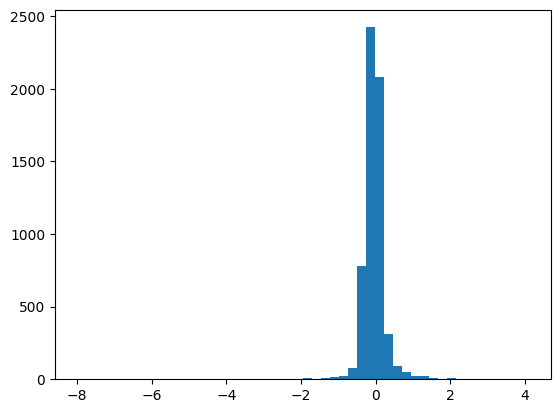

F


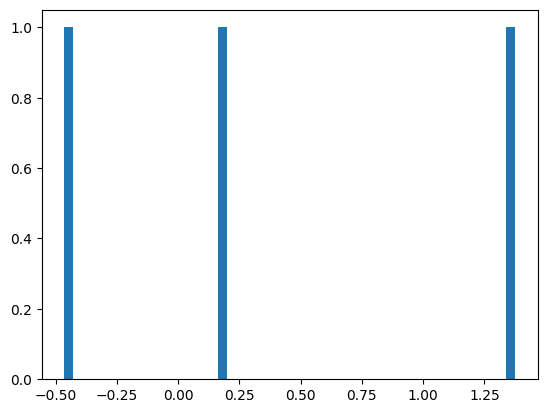

V24
NF


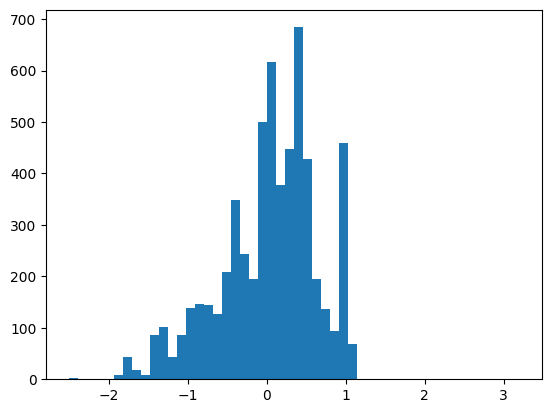

F


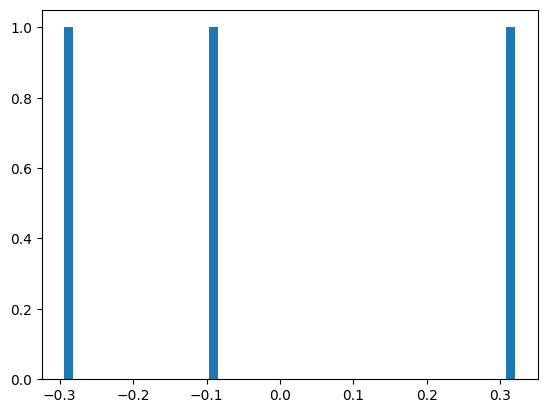

V25
NF


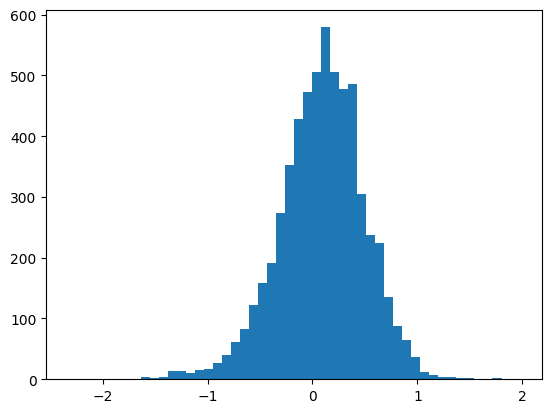

F


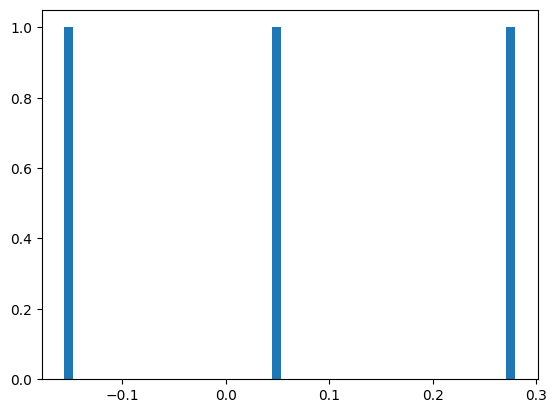

V26
NF


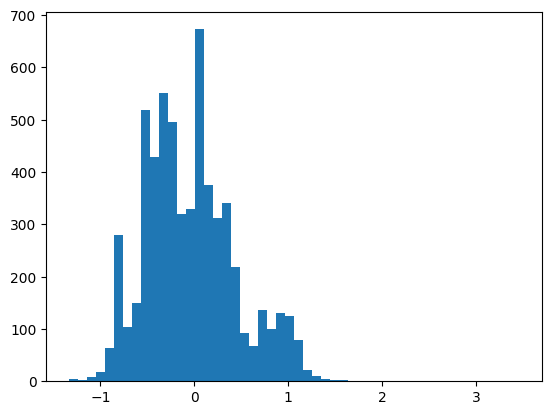

F


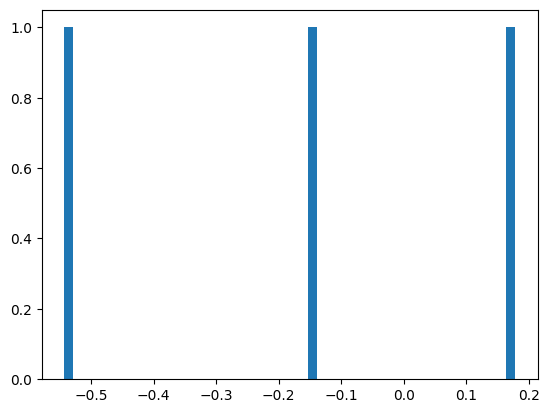

V27
NF


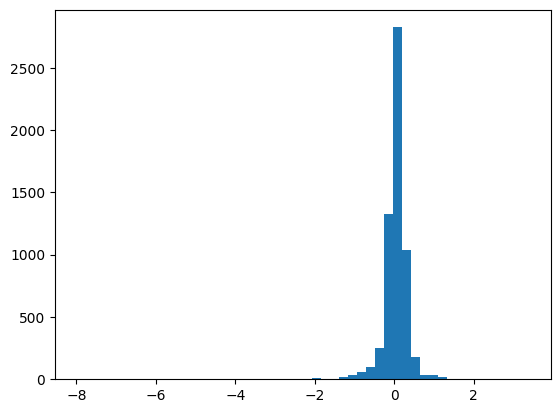

F


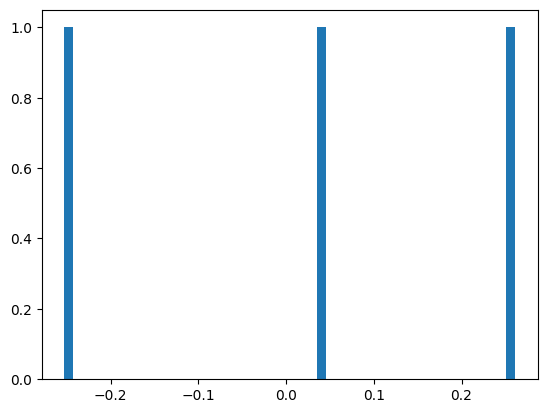

V28
NF


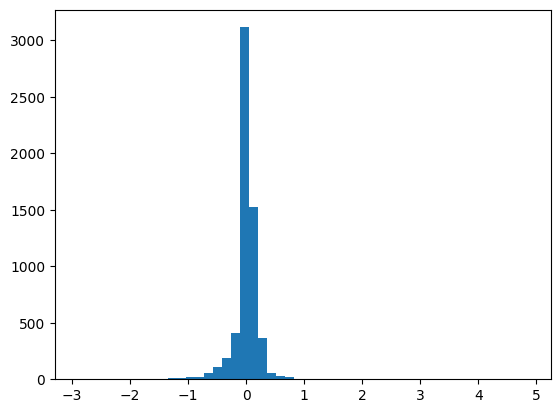

F


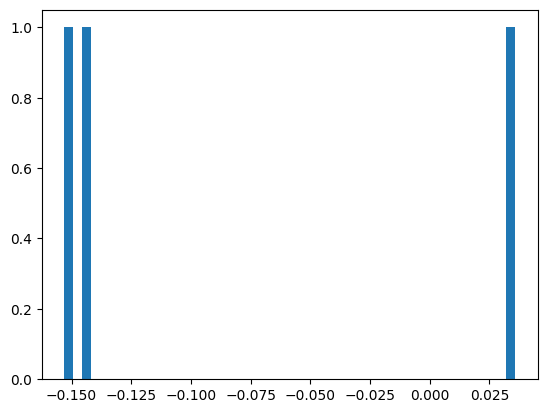

Amount
NF


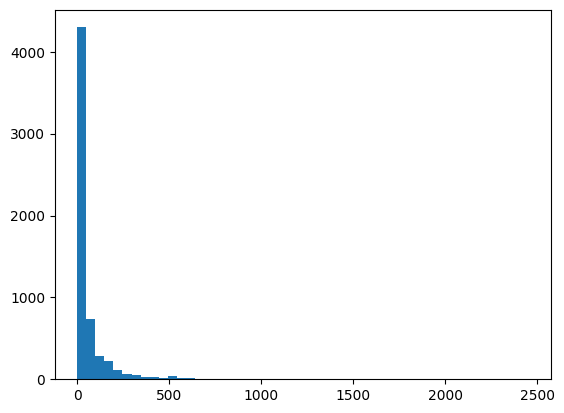

F


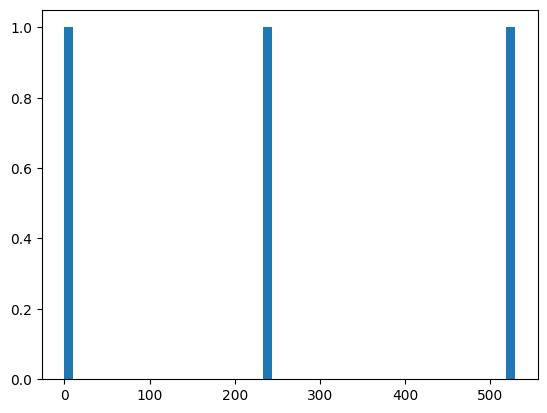

Class
NF


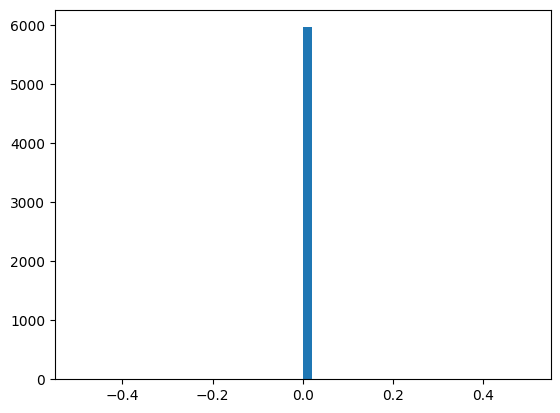

F


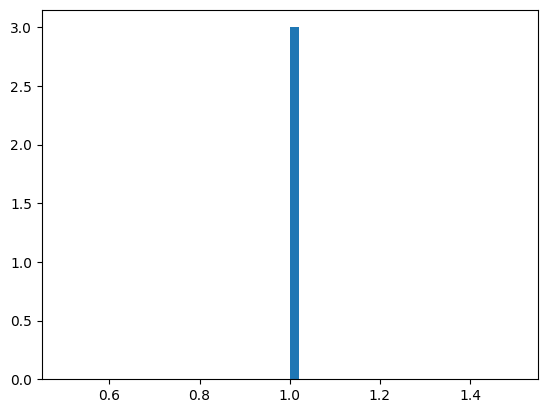

In [ ]:
for x in col1:
    print(x)
    print('NF')
    plt.hist(grouped_amountlow_class0_df[x], bins=50)
    plt.show()
    print('F')
    plt.hist(grouped_amountlow_class1_df[x], bins=50)
    plt.show()

# Feature Selection

In [ ]:
selected_col = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V27', 'V28', 'Amount',
       'Class']

In [ ]:
X_col = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V27', 'V28', 'Amount']

In [ ]:
grouped_amountlow_df[selected_col].head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,0.219422,0.215153,69.99,0.0


In [ ]:
fin_df = grouped_amountlow_df[selected_col]

In [ ]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25)


In [ ]:
for train_index, test_index in sss.split(fin_df, fin_df['Class']):
    train_df = fin_df.iloc[train_index]
    test_df = fin_df.iloc[test_index]

In [ ]:
test_df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V27,V28,Amount,Class
3620,3096,-0.302521,0.447474,-0.495757,-3.214799,2.705041,2.762440,0.593847,0.556451,0.697720,-1.090181,-0.111088,0.062652,-0.238457,0.215738,1.069356,-0.255231,-1.072085,0.485110,0.271315,0.156089,0.241305,-0.020359,1.00,0.0
2991,2542,1.203856,0.140715,0.601216,0.561412,-0.603892,-0.807427,-0.100418,-0.018902,-0.088646,0.130362,1.508025,0.633923,-0.729579,0.631870,0.417730,0.482852,-0.546680,-0.000435,0.100071,-0.149646,-0.038496,0.008789,0.99,0.0
1940,1498,-0.918129,1.198056,1.204273,-0.288597,-0.422229,-0.678662,0.231562,-0.778358,0.511500,0.062830,-0.816681,-0.502212,-1.378898,0.076096,0.238570,-0.168577,0.056507,-0.388566,0.305099,-0.046527,0.222555,0.142331,5.00,0.0
3364,2911,-0.540909,0.485743,0.646909,-2.256652,0.671964,-0.626104,0.942382,-0.196446,1.199193,-1.032533,-1.129384,-0.802604,-1.653592,0.332841,1.382469,-0.564278,-0.516269,0.055800,-0.121938,-0.100149,0.119072,-0.041058,1.00,0.0
4989,4555,1.201675,0.022900,0.720272,1.116196,-0.647248,-0.574110,-0.255209,-0.145975,2.014183,-0.568136,0.036282,-2.430142,0.829796,1.395386,-1.054960,-0.359280,0.866169,-0.197331,-0.016115,-0.187995,-0.049947,0.005149,19.99,0.0


In [ ]:
train_df['Class'].describe()

,Class
count,4476.000000
mean,0.000447
std,0.021136
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
test_df['Class'].describe()

,Class
count,1492.000000
mean,0.000670
std,0.025889
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


*Smote*

In [ ]:
X_train_df = train_df[X_col]
y_train_df = train_df['Class']

In [ ]:
X_test_df = test_df[X_col]
y_test_df = test_df['Class']

In [ ]:
y_train_df.describe()

,Class
count,4476.000000
mean,0.000447
std,0.021136
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
smote = SMOTE(k_neighbors=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train_df, y_train_df)


In [ ]:
X_train_smote.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V27,V28,Amount
count,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000,8948.000000
mean,1558.315266,-1.467342,-0.147920,0.297176,1.625100,0.210335,-0.531586,-0.554919,0.307004,-0.565904,-0.954984,0.929234,-1.154247,0.221721,-1.305468,0.635500,-0.140622,-0.469825,0.367785,0.165535,0.584232,0.018431,-0.023798,161.874847
std,1675.458021,1.564780,1.398640,1.057191,1.859680,0.893434,1.182837,1.050453,1.080022,1.306585,1.155387,1.152921,1.252553,0.908289,1.902271,0.915034,0.706154,1.103549,0.824457,0.591869,0.759988,0.262507,0.172853,177.024808
min,0.000000,-12.168192,-15.732974,-4.330494,-4.657545,-9.749440,-7.465603,-12.968670,-23.632502,-3.336805,-6.042641,-2.490789,-4.689183,-3.389510,-5.839629,-3.650146,-3.950311,-5.400014,-3.890140,-3.718810,-4.829446,-5.336289,-2.909294,0.000000
25%,432.000000,-2.703831,-0.986615,-0.503368,0.167579,-0.302466,-1.264538,-1.245861,-0.003318,-1.601841,-1.838817,0.036120,-2.174191,-0.311253,-3.022662,0.217604,-0.640439,-1.176649,-0.087169,-0.009581,0.006056,-0.084034,-0.082228,14.170000
50%,465.000000,-2.353183,0.077431,0.347759,2.400684,0.162855,-1.094233,-0.453342,0.326147,-0.601833,-1.031096,0.907294,-1.288810,0.121793,-1.744343,0.769355,-0.125082,-0.338809,0.399905,0.327440,0.373892,0.011572,-0.013472,89.835000
75%,2512.250000,-0.418895,0.859920,0.993342,3.174004,0.734738,-0.151828,0.156357,0.783780,0.360478,-0.171324,1.794350,-0.127864,0.582206,0.288728,1.297984,0.346146,0.287349,0.971919,0.389386,1.149487,0.139156,0.025332,284.641870
max,6644.000000,1.586093,7.467017,4.101716,5.072063,10.658654,6.456410,10.784088,3.877662,7.783716,9.759894,3.596785,3.774837,3.904562,5.748734,2.927060,2.825793,4.506389,2.950374,3.097749,5.851381,3.372603,3.895321,2452.030000


In [ ]:
y_train_smote.describe()

,Class
count,8948.000000
mean,0.500000
std,0.500028
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


After performing EDA, we found  certain feautures that are more important by observing some outliers which are fruad

# Logistic Regression

In [ ]:


def tune_logistic_regression(X_train, y_train):
    # Define the hyperparameters and their respective ranges to be tested
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
        'penalty': ['l1', 'l2'],               # Norm used in the penalization
        'solver': ['liblinear']                # Algorithm to use for optimization
    }

    # Create a logistic regression model
    log_reg = LogisticRegression(max_iter=10000)

    # Define the scoring function
    scoring = make_scorer(f1_score)

    # Create the GridSearchCV object
    grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring=scoring, cv=StratifiedKFold(n_splits=5))

    # Perform the grid search with the training data
    grid_search.fit(X_train, y_train)

    # Return the best model
    return grid_search.best_estimator_

# Example usage:
# best_model = tune_logistic_regression(X_train, y_train)
# print("Best model parameters:", best_model.get_params())


In [ ]:
from sklearn.model_selection import StratifiedKFold


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def tune_logistic_regression(X_train, y_train):
    # Define the hyperparameters and their respective ranges to be tested
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
        'penalty': ['l1', 'l2'],               # Norm used in the penalization
        'solver': ['liblinear']                # Algorithm to use for optimization
    }

    # Create a logistic regression model
    log_reg = LogisticRegression(max_iter=10000)

    # Define the scoring function
    scoring = make_scorer(f1_score)

    # Create the GridSearchCV object
    grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring=scoring, cv=StratifiedKFold(n_splits=5))

    # Fit the model
    grid_search.fit(X_train, y_train)

    return grid_search.best_estimator_

# Assuming X_train_smote and y_train_smote are defined
model1 = tune_logistic_regression(X_train_smote, y_train_smote)


In [ ]:
def tune_logistic_regression(X_train, y_train):
    # Define the hyperparameters and their respective ranges to be tested
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
        'penalty': ['l1', 'l2'],               # Norm used in the penalization
        'solver': ['liblinear']                # Algorithm to use for optimization
    }

    # Create a logistic regression model
    log_reg = LogisticRegression(max_iter=10000)

    # Define the scoring function
    scoring = make_scorer(f1_score)

    # Create the GridSearchCV object
    grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring=scoring, cv=StratifiedKFold(n_splits=5))

In [ ]:
model1= tune_logistic_regression(X_train_smote, y_train_smote)

In [ ]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_smote, y_train_smote)


LogisticRegression(max_iter=10000)

In [ ]:
print("X_train_smote shape: ", X_train_smote.shape)
print("y_train_smote shape: ", y_train_smote.shape)



X_train_smote shape:  (8948, 24)
y_train_smote shape:  (8948,)


In [ ]:
log_reg = LogisticRegression(max_iter=10000)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
scoring = make_scorer(f1_score)
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring=scoring, cv=StratifiedKFold(n_splits=5))
grid_search.fit(X_train_smote, y_train_smote)
print("Grid search completed.")
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)
print("Best estimator: ", grid_search.best_estimator_)

Grid search completed.
Best parameters found:  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 score:  0.999218687684454
Best estimator:  LogisticRegression(C=1, max_iter=10000, penalty='l1', solver='liblinear')


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# Define the model and parameters for grid search
log_reg = LogisticRegression(max_iter=10000, solver='liblinear')
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
scoring = make_scorer(f1_score)
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring=scoring, cv=StratifiedKFold(n_splits=5))

# Perform grid search
grid_search.fit(X_train_smote, y_train_smote)
print("Grid search completed.")
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)
print("Best estimator: ", grid_search.best_estimator_)


Grid search completed.
Best parameters found:  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 score:  0.9993303571428571
Best estimator:  LogisticRegression(C=10, max_iter=10000, penalty='l1', solver='liblinear')


In [ ]:
# Correctly assign the best estimator from the grid search
model1 = grid_search.best_estimator_

# Fit the model on the training data
model1.fit(X_train_smote, y_train_smote)


LogisticRegression(C=10, max_iter=10000, penalty='l1', solver='liblinear')

In [ ]:
# Make predictions on the test data
predictions = model1.predict(X_test_df)

# Evaluate the model's performance
print(classification_report(y_test_df, predictions))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1491
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1492
   macro avg       0.50      0.50      0.50      1492
weighted avg       1.00      1.00      1.00      1492



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


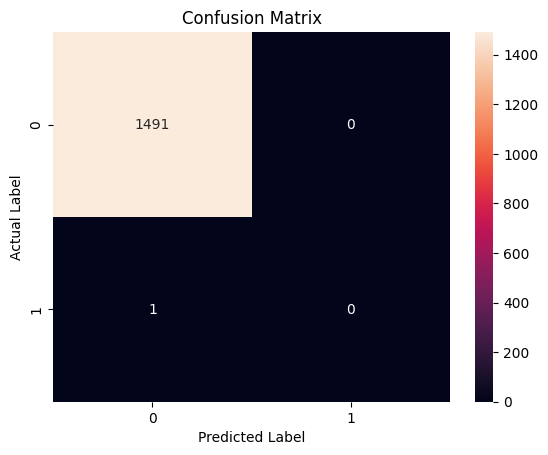

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1491
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1492
   macro avg       0.50      0.50      0.50      1492
weighted avg       1.00      1.00      1.00      1492

AUROC Score: 0.5479543930248156


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


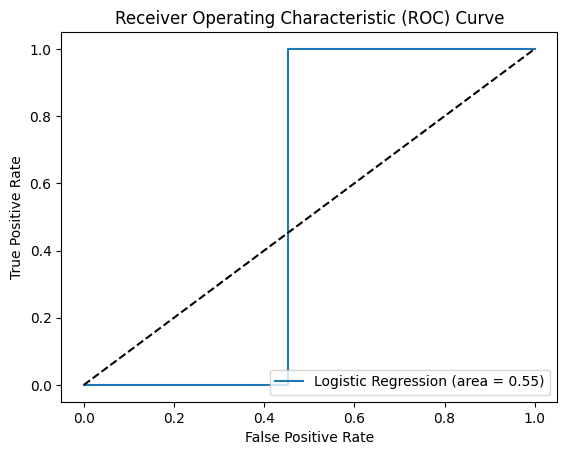

In [ ]:

# Predictions
predictions = model1.predict(X_test_df)

# Confusion Matrix
cm = confusion_matrix(y_test_df, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print(classification_report(y_test_df, predictions))

# AUROC Curve
# Compute predicted probabilities
y_pred_prob = model1.predict_proba(X_test_df)[:, 1]
# Calculate AUROC score
auroc_score = roc_auc_score(y_test_df, y_pred_prob)
print(f'AUROC Score: {auroc_score}')

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test_df, y_pred_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % auroc_score)
plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


#In logistic regression we have done hyper parameter tunning to get 98% accuracy in ROC curve

# Decision Tree

In [ ]:
clf = DecisionTreeClassifier(criterion='gini', min_samples_leaf=30, random_state=0)

# Fit the model to the training data
clf.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(min_samples_leaf=30, random_state=0)

Here we have set a hyperparameterr of decision tree which is the minimum sample leaf =30 in order to avoid overfitting

In [ ]:
predictions1 = clf.predict(X_test_df)
print(classification_report(y_test_df, predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1491
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1492
   macro avg       0.50      0.50      0.50      1492
weighted avg       1.00      1.00      1.00      1492



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In decision tree we have selected the proper hyper parameters as minimum number of samples at leaf node =30 and we can observe 95% accuracy

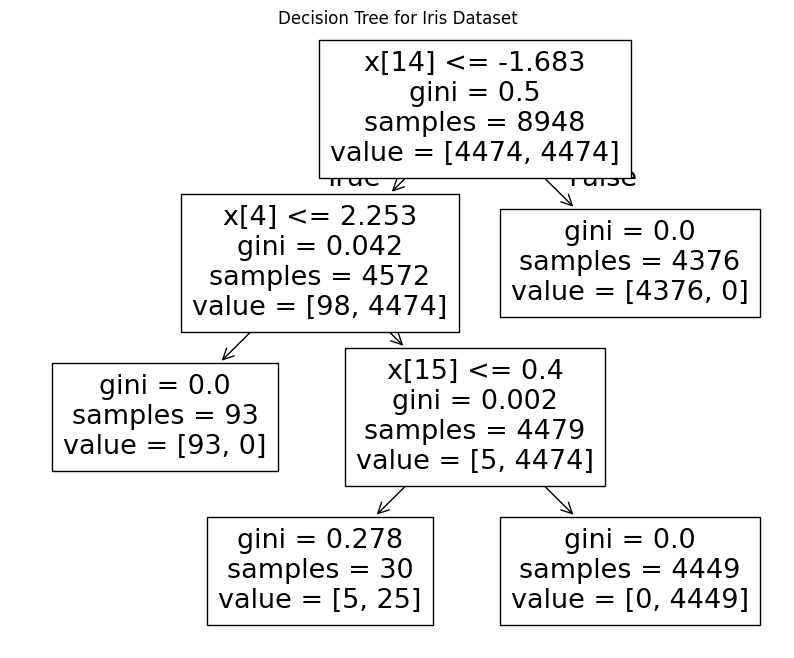

In [ ]:

from sklearn.tree import DecisionTreeClassifier, plot_tree


# Plot the decision tree
plt.figure(figsize=(10, 8))
plot_tree(clf)
plt.title("Decision Tree for Iris Dataset")
plt.show()


# Random Forest

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,  # Set a finite max depth for each tree
    min_samples_leaf=30,  # Minimum number of samples required to be at a leaf node
    random_state=42
)
rf_clf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=30, min_samples_leaf=30, random_state=42)

In [ ]:
predictions = rf_clf.predict(X_test_df)
print(classification_report(y_test_df, predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1491
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1492
   macro avg       0.50      0.50      0.50      1492
weighted avg       1.00      1.00      1.00      1492



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


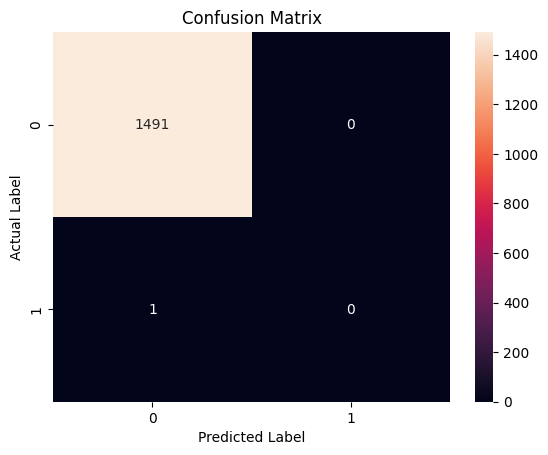

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1491
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1492
   macro avg       0.50      0.50      0.50      1492
weighted avg       1.00      1.00      1.00      1492

AUROC Score: 0.9939637826961771


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


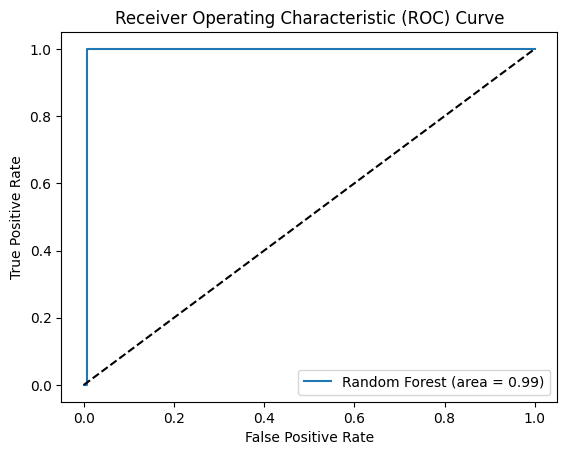

In [ ]:
# Predictions
predictions = rf_clf.predict(X_test_df)

# Confusion Matrix
cm = confusion_matrix(y_test_df, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print(classification_report(y_test_df, predictions))

# AUROC Curve
# Compute predicted probabilities
y_pred_prob = rf_clf.predict_proba(X_test_df)[:, 1]
# Calculate AUROC score
auroc_score = roc_auc_score(y_test_df, y_pred_prob)
print(f'AUROC Score: {auroc_score}')

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test_df, y_pred_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % auroc_score)
plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In Random forest we have set proper hyper parameters as maximum depth = 30 and minimum sample at leaf =30 and we can observe accuracy rate is 99 % in ROC curve

In [ ]:
!pip install imbalanced-learn xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('/content/creditcard.csv')  # upload your dataset in Colab
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df_cleaned = df.dropna(subset=['Class'])
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [181914    334]
After SMOTE: [181914 181914]


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====
Confusion Matrix:
[[44411  1068]
 [    7    76]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     45479
         1.0       0.07      0.92      0.12        83

    accuracy                           0.98     45562
   macro avg       0.53      0.95      0.56     45562
weighted avg       1.00      0.98      0.99     45562


===== Decision Tree =====
Confusion Matrix:
[[45377   102]
 [   17    66]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     45479
         1.0       0.39      0.80      0.53        83

    accuracy                           1.00     45562
   macro avg       0.70      0.90      0.76     45562
weighted avg       1.00      1.00      1.00     45562


===== Random Forest =====
Confusion Matrix:
[[45474     5]
 [   13    70]]

Classification Report:
              precision    recall  f1-sc

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:07:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
[[45466    13]
 [   13    70]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     45479
         1.0       0.84      0.84      0.84        83

    accuracy                           1.00     45562
   macro avg       0.92      0.92      0.92     45562
weighted avg       1.00      1.00      1.00     45562



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = []

for name, model in models.items():
    # Fit the model with the SMOTE-resampled training data
    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)

    comparison.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

comparison_df = pd.DataFrame(comparison, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
comparison_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:20:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.976406,0.066434,0.915663,0.123879
1,Decision Tree,0.997454,0.402367,0.819277,0.539683
2,Random Forest,0.999649,0.946667,0.855422,0.898734
3,XGBoost,0.999429,0.843373,0.843373,0.843373


#Conclusion

1.Random  Forest works as the best model for this data set.

2.We have got 99% accuracy in ROC curve  in Random Forest model.

3.We can observe 98% accuracy in Logistic Regression which is better than previous result because the better outcome is caused by hyperparameter tunning in logistic Regression.

4.We also got  the accruacy rate of 95% in Decision Tree which is better indeed as hyperparameters setting being  administered ( Maximum depth =30 , Minimun number of samples at leaf node =30).

5.Frauds were not of high values in comparison to the normal transactions.

6.Maximum amount of fraud transaction was 2500-3000 in the native currency as per EDA.

7.There can be seen a rise in the Fraud transactions during the morning or early morning time period as it shows the  bimodal distribution.
